In [4]:
!pip install torch-geometric pandas numpy matplotlib seaborn networkx scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00


In [5]:
import torch
import torch_geometric
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

PyTorch: 2.11.0+cu128
PyG: 2.8.0.post1


In [6]:
!pip install omnipath

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.0 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19973 sha256=cc6d00f2deaa24a188740193c7b4d3975a83aa5c0863c03f43621bc4314a4bf5
  Stored in directory: /root/.cache/pip/wheels/45/f2/42/d9ffbaceb3f12c063124529560e5a8b5ec85930e6f8ba5a017
Successfully built docrep


In [7]:
import requests
import pandas as pd
from io import StringIO

url = (
    "https://omnipathdb.org/interactions"
    "?datasets=dorothea"
    "&organisms=9606"
    "&genesymbols=yes"
    "&dorothea_levels=A,B,C"
)

response = requests.get(url)

print(response.status_code)
print(response.text[:500])

200
source	target	source_genesymbol	target_genesymbol	is_directed	is_stimulation	is_inhibition	consensus_direction	consensus_stimulation	consensus_inhibition
P84022	P05412	SMAD3	JUN	True	True	False	True	True	False
P01106	O14746	MYC	TERT	True	True	False	True	True	False
Q13485	P05412	SMAD4	JUN	True	True	False	True	True	False
P08047	P04075	SP1	ALDOA	True	True	False	True	True	False
P04637	P08069	TP53	IGF1R	True	False	True	True	False	True
Q05516	P20248	ZBTB16	CCNA2	True	False	True	True	False	True
Q01196	


In [8]:
df = pd.read_csv(
    StringIO(response.text),
    sep="\t"
)

df.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,P84022,P05412,SMAD3,JUN,True,True,False,True,True,False
1,P01106,O14746,MYC,TERT,True,True,False,True,True,False
2,Q13485,P05412,SMAD4,JUN,True,True,False,True,True,False
3,P08047,P04075,SP1,ALDOA,True,True,False,True,True,False
4,P04637,P08069,TP53,IGF1R,True,False,True,True,False,True


In [9]:
print(df.shape)
print(df.columns.tolist())

(32629, 10)
['source', 'target', 'source_genesymbol', 'target_genesymbol', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']


In [10]:
df.head(10)

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,P84022,P05412,SMAD3,JUN,True,True,False,True,True,False
1,P01106,O14746,MYC,TERT,True,True,False,True,True,False
2,Q13485,P05412,SMAD4,JUN,True,True,False,True,True,False
3,P08047,P04075,SP1,ALDOA,True,True,False,True,True,False
4,P04637,P08069,TP53,IGF1R,True,False,True,True,False,True
5,Q05516,P20248,ZBTB16,CCNA2,True,False,True,True,False,True
6,Q01196,P08700,RUNX1,IL3,True,False,True,True,False,True
7,P42224,P38936,STAT1,CDKN1A,True,True,False,True,True,False
8,P40763,P38936,STAT3,CDKN1A,True,True,False,True,True,False
9,P04637,P06400,TP53,RB1,True,True,True,True,True,False


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   source                 32629 non-null  object
 1   target                 32629 non-null  object
 2   source_genesymbol      32629 non-null  object
 3   target_genesymbol      32629 non-null  object
 4   is_directed            32629 non-null  bool  
 5   is_stimulation         32629 non-null  bool  
 6   is_inhibition          32629 non-null  bool  
 7   consensus_direction    32629 non-null  bool  
 8   consensus_stimulation  32629 non-null  bool  
 9   consensus_inhibition   32629 non-null  bool  
dtypes: bool(6), object(4)
memory usage: 1.2+ MB


In [12]:
df = df.drop_duplicates()

In [13]:
df = df.dropna(subset=["source_genesymbol", "target_genesymbol"])

In [14]:
df["source_genesymbol"].nunique()

429

In [15]:
df["target_genesymbol"].nunique()

9228

In [16]:
len(df)

32629

In [17]:
print(df.columns.tolist())

['source', 'target', 'source_genesymbol', 'target_genesymbol', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']


In [18]:
print(df.shape)
display(df.head())

(32629, 10)


,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,P84022,P05412,SMAD3,JUN,True,True,False,True,True,False
1,P01106,O14746,MYC,TERT,True,True,False,True,True,False
2,Q13485,P05412,SMAD4,JUN,True,True,False,True,True,False
3,P08047,P04075,SP1,ALDOA,True,True,False,True,True,False
4,P04637,P08069,TP53,IGF1R,True,False,True,True,False,True


In [19]:
print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

print("\nFirst 5 rows:")
display(df.head())

Shape: (32629, 10)

Columns:
0 -> source
1 -> target
2 -> source_genesymbol
3 -> target_genesymbol
4 -> is_directed
5 -> is_stimulation
6 -> is_inhibition
7 -> consensus_direction
8 -> consensus_stimulation
9 -> consensus_inhibition

First 5 rows:


,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,P84022,P05412,SMAD3,JUN,True,True,False,True,True,False
1,P01106,O14746,MYC,TERT,True,True,False,True,True,False
2,Q13485,P05412,SMAD4,JUN,True,True,False,True,True,False
3,P08047,P04075,SP1,ALDOA,True,True,False,True,True,False
4,P04637,P08069,TP53,IGF1R,True,False,True,True,False,True


In [20]:
print("Missing values:")
print(df.isna().sum())

print("\nNumber of unique TFs:")
print(df["source_genesymbol"].nunique())

print("\nNumber of unique target genes:")
print(df["target_genesymbol"].nunique())

print("\nNumber of unique interactions:")
print(df[["source_genesymbol", "target_genesymbol"]].drop_duplicates().shape[0])

Missing values:
source                   0
target                   0
source_genesymbol        0
target_genesymbol        0
is_directed              0
is_stimulation           0
is_inhibition            0
consensus_direction      0
consensus_stimulation    0
consensus_inhibition     0
dtype: int64

Number of unique TFs:
429

Number of unique target genes:
9228

Number of unique interactions:
32286


In [21]:

print("is_stimulation:")
print(df["is_stimulation"].value_counts(dropna=False))

print("\nis_inhibition:")
print(df["is_inhibition"].value_counts(dropna=False))

print("\nconsensus_direction:")
print(df["consensus_direction"].value_counts(dropna=False))

is_stimulation:
is_stimulation
False    25616
True      7013
Name: count, dtype: int64

is_inhibition:
is_inhibition
False    31090
True      1539
Name: count, dtype: int64

consensus_direction:
consensus_direction
False    24977
True      7652
Name: count, dtype: int64


In [22]:
# ============================================
# STEP 2 — Clean DoRothEA regulatory network
# ============================================


network_df = df[
    [
        "source_genesymbol",
        "target_genesymbol",
        "is_directed",
        "is_stimulation",
        "is_inhibition",
        "consensus_direction",
        "consensus_stimulation",
        "consensus_inhibition"
    ]
].copy()

network_df = network_df.rename(
    columns={
        "source_genesymbol": "TF",
        "target_genesymbol": "Target"
    }
)

network_df = network_df.drop_duplicates(
    subset=["TF", "Target"]
).reset_index(drop=True)

print("Final network shape:", network_df.shape)

print("\nNumber of TFs:",
      network_df["TF"].nunique())

print("Number of target genes:",
      network_df["Target"].nunique())

print("\nFirst 10 interactions:")
display(network_df.head(10))

Final network shape: (32286, 8)

Number of TFs: 429
Number of target genes: 9228

First 10 interactions:


,TF,Target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,SMAD3,JUN,True,True,False,True,True,False
1,MYC,TERT,True,True,False,True,True,False
2,SMAD4,JUN,True,True,False,True,True,False
3,SP1,ALDOA,True,True,False,True,True,False
4,TP53,IGF1R,True,False,True,True,False,True
5,ZBTB16,CCNA2,True,False,True,True,False,True
6,RUNX1,IL3,True,False,True,True,False,True
7,STAT1,CDKN1A,True,True,False,True,True,False
8,STAT3,CDKN1A,True,True,False,True,True,False
9,TP53,RB1,True,True,True,True,True,False


In [23]:
# ============================================
# STEP 2.1 — Basic regulatory statistics
# ============================================

print("Total unique TF-target interactions:",
      len(network_df))

print("\nDirected interactions:")
print(network_df["is_directed"].value_counts())

print("\nStimulation:")
print(network_df["is_stimulation"].value_counts())

print("\nInhibition:")
print(network_df["is_inhibition"].value_counts())

print("\nConsensus direction:")
print(network_df["consensus_direction"].value_counts())

Total unique TF-target interactions: 32286

Directed interactions:
is_directed
True    32286
Name: count, dtype: int64

Stimulation:
is_stimulation
False    25332
True      6954
Name: count, dtype: int64

Inhibition:
is_inhibition
False    30761
True      1525
Name: count, dtype: int64

Consensus direction:
consensus_direction
False    24699
True      7587
Name: count, dtype: int64


In [24]:
# ============================================
# STEP 2.2 — Check regulatory consistency
# ============================================

both = network_df[
    (network_df["is_stimulation"] == True) &
    (network_df["is_inhibition"] == True)
]

print("Interactions marked as BOTH stimulation and inhibition:",
      len(both))

display(both.head(20))

Interactions marked as BOTH stimulation and inhibition: 598


,TF,Target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
9,TP53,RB1,True,True,True,True,True,False
11,TP53,CDKN1A,True,True,True,True,True,False
22,ETS1,TIMP1,True,True,True,True,True,False
29,JUN,CCND1,True,True,True,True,True,False
31,HNF4A,GUCY2C,True,True,True,True,False,True
33,JUN,CDKN1A,True,True,True,True,False,True
38,AR,KLK3,True,True,True,True,True,False
43,RARG,RARB,True,True,True,True,False,True
72,TP53,GADD45A,True,True,True,True,True,False
88,STAT1,IFNG,True,True,True,True,True,False


In [25]:
# ============================================
# STEP 2.3 — Self-regulation check
# ============================================

self_loops = network_df[
    network_df["TF"] == network_df["Target"]
]

print("Self-regulatory interactions:",
      len(self_loops))

display(self_loops.head(20))

Self-regulatory interactions: 0


,TF,Target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition


In [26]:
!pip install networkx matplotlib

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [28]:
# ============================================
# STEP 3 — Build directed gene regulatory graph
# ============================================

G = nx.DiGraph()

for _, row in network_df.iterrows():

    G.add_edge(
        row["TF"],
        row["Target"],
        is_stimulation=row["is_stimulation"],
        is_inhibition=row["is_inhibition"],
        consensus_direction=row["consensus_direction"],
        consensus_stimulation=row["consensus_stimulation"],
        consensus_inhibition=row["consensus_inhibition"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 9300
Number of edges: 32286


In [29]:
# ============================================
# STEP 3.1 — Basic graph statistics
# ============================================

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

density = nx.density(G)

print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Network density:", density)

print("\nIs directed:", G.is_directed())
print("Is weighted:", nx.is_weighted(G))

Nodes: 9300
Edges: 32286
Network density: 0.00037333185323430544

Is directed: True
Is weighted: False


In [30]:
# ============================================
# STEP 3.2 — TF out-degree
# ============================================

tf_out_degree = (
    network_df
    .groupby("TF")["Target"]
    .nunique()
    .sort_values(ascending=False)
)

print("Top 20 TFs by number of target genes:")

display(
    tf_out_degree
    .head(20)
    .to_frame("Number_of_Target_Genes")
)

Top 20 TFs by number of target genes:


,Number_of_Target_Genes
TF,
STAT1,1129
EGR1,1001
CEBPA,1001
ETS1,979
CTCF,975
HNF4A,934
TFAP2C,915
FOS,877
FOXA1,866


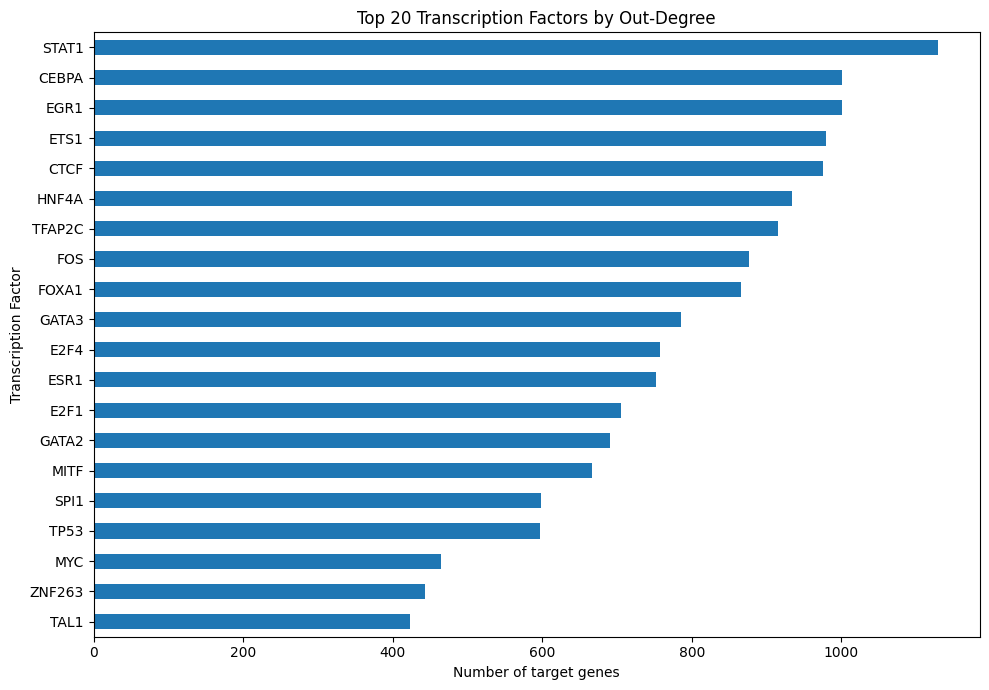

In [31]:
# ============================================
# STEP 3.3 — Top 20 TF visualization
# ============================================

top20 = tf_out_degree.head(20).sort_values()

plt.figure(figsize=(10, 7))

top20.plot(kind="barh")

plt.xlabel("Number of target genes")
plt.ylabel("Transcription Factor")
plt.title("Top 20 Transcription Factors by Out-Degree")

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# STEP 3.4 — Target gene in-degree
# ============================================

target_in_degree = (
    network_df
    .groupby("Target")["TF"]
    .nunique()
    .sort_values(ascending=False)
)

print("Top 20 target genes by number of regulating TFs:")

display(
    target_in_degree
    .head(20)
    .to_frame("Number_of_TFs")
)

Top 20 target genes by number of regulating TFs:


,Number_of_TFs
Target,
SEPTIN9,57
FOXP1,53
RUNX1,53
MYC,50
CDKN1A,47
MACF1,47
CCND1,44
DST,44
SMAD3,43


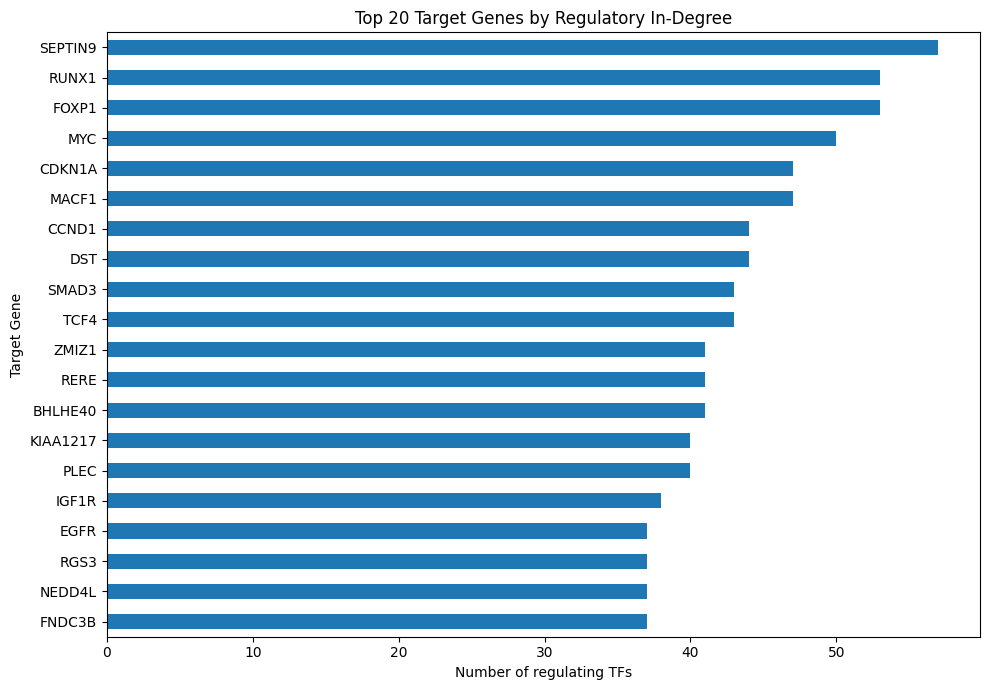

In [33]:
top20_targets = target_in_degree.head(20).sort_values()

plt.figure(figsize=(10, 7))

top20_targets.plot(kind="barh")

plt.xlabel("Number of regulating TFs")
plt.ylabel("Target Gene")
plt.title("Top 20 Target Genes by Regulatory In-Degree")

plt.tight_layout()
plt.show()

In [34]:
# ============================================
# STEP 3.5 — Regulatory direction statistics
# ============================================

total = len(network_df)

stimulation_count = network_df["is_stimulation"].sum()
inhibition_count = network_df["is_inhibition"].sum()
consensus_count = network_df["consensus_direction"].sum()

print(f"Total interactions: {total:,}")

print(
    f"Stimulation: {stimulation_count:,} "
    f"({100 * stimulation_count / total:.2f}%)"
)

print(
    f"Inhibition: {inhibition_count:,} "
    f"({100 * inhibition_count / total:.2f}%)"
)

print(
    f"Consensus direction: {consensus_count:,} "
    f"({100 * consensus_count / total:.2f}%)"
)

Total interactions: 32,286
Stimulation: 6,954 (21.54%)
Inhibition: 1,525 (4.72%)
Consensus direction: 7,587 (23.50%)


In [35]:
# ============================================
# STEP 3.6 — Investigate stimulation + inhibition
# ============================================

both = network_df[
    (network_df["is_stimulation"] == True) &
    (network_df["is_inhibition"] == True)
].copy()

print("Interactions marked as both stimulation and inhibition:")
print(len(both))

print("\nConsensus stimulation:")
print(both["consensus_stimulation"].value_counts())

print("\nConsensus inhibition:")
print(both["consensus_inhibition"].value_counts())

print("\nConsensus direction:")
print(both["consensus_direction"].value_counts())

Interactions marked as both stimulation and inhibition:
598

Consensus stimulation:
consensus_stimulation
False    301
True     297
Name: count, dtype: int64

Consensus inhibition:
consensus_inhibition
False    303
True     295
Name: count, dtype: int64

Consensus direction:
consensus_direction
True     571
False     27
Name: count, dtype: int64


                 HUMAN TF–GENE DATA
                         │
                         ▼
              Regulatory Network
                 32,286 edges
                         │
          ┌──────────────┴──────────────┐
          ▼                             ▼
   Network Analysis                 GNN Model
          │                             │
          ▼                             ▼
   Regulatory Hubs               Link Prediction
          │                             │
          └──────────────┬──────────────┘
                         ▼
                   Explainability
                         │
                         ▼
              High-confidence edges
                         │
                         ▼
             Independent validation
                    (ENCODE)
                         │
                         ▼
               Disease subnetwork
                         │
                         ▼
              Biological enrichment

In [36]:
# ============================================
# STEP 4.1 — Network Structure Summary
# ============================================

print("============================================")
print("STEP 4.1 — Network Structure Summary")
print("============================================")

# Number of unique TFs
n_tfs = network_df["TF"].nunique()

# Number of unique target genes
n_targets = network_df["Target"].nunique()

# Number of unique nodes across both sides
all_nodes = set(network_df["TF"]) | set(network_df["Target"])
n_nodes = len(all_nodes)

# TFs that also appear as target genes
tf_set = set(network_df["TF"])
target_set = set(network_df["Target"])

overlap = tf_set & target_set

# Number of unique TF-target interactions
n_edges = network_df[["TF", "Target"]].drop_duplicates().shape[0]

print(f"Unique TFs: {n_tfs}")
print(f"Unique target genes: {n_targets}")
print(f"Unique nodes: {n_nodes}")
print(f"TF-target overlap: {len(overlap)}")
print(f"Unique TF-target edges: {n_edges}")

print("\nFirst 20 overlapping TF/target genes:")
print(sorted(overlap)[:20])

STEP 4.1 — Network Structure Summary
Unique TFs: 429
Unique target genes: 9228
Unique nodes: 9300
TF-target overlap: 357
Unique TF-target edges: 32286

First 20 overlapping TF/target genes:
['ADNP', 'AHR', 'AR', 'ARID2', 'ARID3A', 'ARNT', 'ASCL1', 'ATF1', 'ATF2', 'ATF3', 'ATF4', 'ATF6', 'ATF7', 'ATOH1', 'BACH1', 'BACH2', 'BATF', 'BCL11A', 'BCL6', 'BHLHE40']


In [37]:
# ============================================
# STEP 4.2 — TF Regulatory Degree
# ============================================

tf_degree = (
    network_df
    .groupby("TF")["Target"]
    .nunique()
    .reset_index(name="Number_of_Target_Genes")
    .sort_values("Number_of_Target_Genes", ascending=False)
)

print("Top 30 TFs by number of target genes:")
display(tf_degree.head(30))


Top 30 TFs by number of target genes:


,TF,Number_of_Target_Genes
345,STAT1,1129
56,EGR1,1001
26,CEBPA,1001
75,ETS1,979
39,CTCF,975
130,HNF4A,934
369,TFAP2C,915
82,FOS,877
86,FOXA1,866
106,GATA3,785


In [38]:
# ============================================
# STEP 4.3 — Target Gene Regulatory Degree
# ============================================

target_degree = (
    network_df
    .groupby("Target")["TF"]
    .nunique()
    .reset_index(name="Number_of_TFs")
    .sort_values("Number_of_TFs", ascending=False)
)

print("Top 30 target genes by number of regulating TFs:")
display(target_degree.head(30))

Top 30 target genes by number of regulating TFs:


,Target,Number_of_TFs
7008,SEPTIN9,57
2933,FOXP1,53
6838,RUNX1,53
4952,MYC,50
1377,CDKN1A,47
4467,MACF1,47
1217,CCND1,44
2293,DST,44
7360,SMAD3,43
7891,TCF4,43


In [39]:
# ============================================
# STEP 4.4 — TF Activation/Inhibition Profile
# ============================================

top_tfs = tf_degree.head(30)["TF"].tolist()

tf_direction_profile = (
    network_df[network_df["TF"].isin(top_tfs)]
    .groupby("TF")
    .agg(
        Total_Targets=("Target", "nunique"),
        Stimulation=("is_stimulation", "sum"),
        Inhibition=("is_inhibition", "sum"),
        Consensus_Direction=("consensus_direction", "sum")
    )
    .reset_index()
)

# Calculate percentages
tf_direction_profile["Stimulation_%"] = (
    tf_direction_profile["Stimulation"] /
    tf_direction_profile["Total_Targets"] * 100
)

tf_direction_profile["Inhibition_%"] = (
    tf_direction_profile["Inhibition"] /
    tf_direction_profile["Total_Targets"] * 100
)

tf_direction_profile = tf_direction_profile.sort_values(
    "Total_Targets",
    ascending=False
)

display(tf_direction_profile)

,TF,Total_Targets,Stimulation,Inhibition,Consensus_Direction,Stimulation_%,Inhibition_%
24,STAT1,1129,315,45,344,27.900797,3.985828
1,CEBPA,1001,163,22,167,16.283716,2.197802
5,EGR1,1001,158,34,166,15.784216,3.396603
7,ETS1,979,167,23,167,17.058223,2.349336
2,CTCF,975,112,45,146,11.487179,4.615385
14,HNF4A,934,128,26,142,13.704497,2.783726
26,TFAP2C,915,16,3,17,1.748634,0.327869
8,FOS,877,122,21,115,13.911060,2.394527
9,FOXA1,866,39,12,49,4.503464,1.385681
12,GATA3,785,83,21,92,10.573248,2.675159


In [40]:
Stimulation=("is_stimulation", "sum")

In [41]:
# ============================================
# STEP 4.5 — Detailed Directionality Profile
# ============================================

top_tfs = tf_degree.head(30)["TF"].tolist()

hub_edges = network_df[
    network_df["TF"].isin(top_tfs)
].copy()

direction_profile = (
    hub_edges
    .groupby("TF")
    .apply(
        lambda g: pd.Series({
            "Total_Targets": g["Target"].nunique(),

            "Stimulation_only": g.loc[
                (g["is_stimulation"] == True) &
                (g["is_inhibition"] == False),
                "Target"
            ].nunique(),

            "Inhibition_only": g.loc[
                (g["is_stimulation"] == False) &
                (g["is_inhibition"] == True),
                "Target"
            ].nunique(),

            "Both": g.loc[
                (g["is_stimulation"] == True) &
                (g["is_inhibition"] == True),
                "Target"
            ].nunique(),

            "No_direction": g.loc[
                (g["is_stimulation"] == False) &
                (g["is_inhibition"] == False),
                "Target"
            ].nunique()
        })
    )
    .reset_index()
)

direction_profile = direction_profile.sort_values(
    "Total_Targets",
    ascending=False
)

display(direction_profile)

/tmp/ipykernel_864/4010209920.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,TF,Total_Targets,Stimulation_only,Inhibition_only,Both,No_direction
24,STAT1,1129,302,32,13,782
1,CEBPA,1001,159,18,4,820
5,EGR1,1001,149,25,9,818
7,ETS1,979,154,10,13,802
2,CTCF,975,102,35,10,828
14,HNF4A,934,120,18,8,788
26,TFAP2C,915,14,1,2,898
8,FOS,877,108,7,14,748
9,FOXA1,866,37,10,2,817
12,GATA3,785,78,16,5,686


In [42]:
# ============================================
# STEP 4.6 — Directionality Coverage
# ============================================

direction_profile["Directional_Annotated"] = (
    direction_profile["Stimulation_only"]
    + direction_profile["Inhibition_only"]
    + direction_profile["Both"]
)

direction_profile["Directional_Coverage_%"] = (
    direction_profile["Directional_Annotated"]
    / direction_profile["Total_Targets"]
    * 100
)

direction_profile["Both_%"] = (
    direction_profile["Both"]
    / direction_profile["Total_Targets"]
    * 100
)

direction_profile["No_Direction_%"] = (
    direction_profile["No_direction"]
    / direction_profile["Total_Targets"]
    * 100
)

direction_profile = direction_profile.sort_values(
    "Directional_Coverage_%",
    ascending=False
)

display(direction_profile)

,TF,Total_Targets,Stimulation_only,Inhibition_only,Both,No_direction,Directional_Annotated,Directional_Coverage_%,Both_%,No_Direction_%
16,MYC,465,362,26,23,54,411,88.387097,4.946237,11.612903
22,SP1,394,312,9,26,47,347,88.071066,6.598985,11.928934
19,RELA,243,137,20,37,49,194,79.835391,15.226337,20.164609
17,NFKB1,250,152,8,39,51,199,79.600000,15.600000,20.400000
0,AR,225,124,8,15,78,147,65.333333,6.666667,34.666667
13,HIF1A,262,153,4,12,93,169,64.503817,4.580153,35.496183
27,TP53,597,223,76,42,256,341,57.118928,7.035176,42.881072
3,E2F1,706,323,13,11,359,347,49.150142,1.558074,50.849858
6,ESR1,752,196,34,19,503,249,33.111702,2.526596,66.888298
4,E2F4,757,217,24,4,512,245,32.364597,0.528402,67.635403


In [43]:
# ============================================
# STEP 4.7 — Final Hub Summary
# ============================================

hub_summary = direction_profile[
    [
        "TF",
        "Total_Targets",
        "Directional_Annotated",
        "Directional_Coverage_%",
        "Stimulation_only",
        "Inhibition_only",
        "Both",
        "Both_%",
        "No_direction",
        "No_Direction_%"
    ]
].copy()

# Sort by network connectivity
hub_summary = hub_summary.sort_values(
    "Total_Targets",
    ascending=False
)

display(hub_summary)

,TF,Total_Targets,Directional_Annotated,Directional_Coverage_%,Stimulation_only,Inhibition_only,Both,Both_%,No_direction,No_Direction_%
24,STAT1,1129,347,30.735164,302,32,13,1.151461,782,69.264836
5,EGR1,1001,183,18.281718,149,25,9,0.899101,818,81.718282
1,CEBPA,1001,181,18.081918,159,18,4,0.399600,820,81.918082
7,ETS1,979,177,18.079673,154,10,13,1.327886,802,81.920327
2,CTCF,975,147,15.076923,102,35,10,1.025641,828,84.923077
14,HNF4A,934,146,15.631692,120,18,8,0.856531,788,84.368308
26,TFAP2C,915,17,1.857923,14,1,2,0.218579,898,98.142077
8,FOS,877,129,14.709236,108,7,14,1.596351,748,85.290764
9,FOXA1,866,49,5.658199,37,10,2,0.230947,817,94.341801
12,GATA3,785,99,12.611465,78,16,5,0.636943,686,87.388535


In [44]:
# ============================================
# STEP 4.8 — Global Directionality Check
# ============================================

global_direction = {
    "Total unique interactions":
        network_df[["TF", "Target"]].drop_duplicates().shape[0],

    "Stimulation only":
        network_df[
            (network_df["is_stimulation"] == True) &
            (network_df["is_inhibition"] == False)
        ][["TF", "Target"]].drop_duplicates().shape[0],

    "Inhibition only":
        network_df[
            (network_df["is_stimulation"] == False) &
            (network_df["is_inhibition"] == True)
        ][["TF", "Target"]].drop_duplicates().shape[0],

    "Both":
        network_df[
            (network_df["is_stimulation"] == True) &
            (network_df["is_inhibition"] == True)
        ][["TF", "Target"]].drop_duplicates().shape[0],

    "No direction":
        network_df[
            (network_df["is_stimulation"] == False) &
            (network_df["is_inhibition"] == False)
        ][["TF", "Target"]].drop_duplicates().shape[0]
}

global_direction_df = pd.DataFrame(
    list(global_direction.items()),
    columns=["Category", "Number_of_Interactions"]
)

display(global_direction_df)

,Category,Number_of_Interactions
0,Total unique interactions,32286
1,Stimulation only,6356
2,Inhibition only,927
3,Both,598
4,No direction,24405


In [45]:
# ============================================
# STEP 5.1 — Prepare Graph for PyTorch Geometric
# ============================================

import torch
from torch_geometric.data import Data

# --------------------------------------------
# 1. Create unified node list
# --------------------------------------------

all_nodes = sorted(
    set(network_df["TF"]) |
    set(network_df["Target"])
)

node_to_idx = {
    node: idx
    for idx, node in enumerate(all_nodes)
}

idx_to_node = {
    idx: node
    for node, idx in node_to_idx.items()
}

print("Number of nodes:", len(all_nodes))


# --------------------------------------------
# 2. Convert TF-target pairs to integer indices
# --------------------------------------------

source_idx = network_df["TF"].map(node_to_idx).values
target_idx = network_df["Target"].map(node_to_idx).values


# --------------------------------------------
# 3. Build directed edge index
# --------------------------------------------

edge_index = torch.tensor(
    [source_idx, target_idx],
    dtype=torch.long
)


# --------------------------------------------
# 4. Create PyG graph
# --------------------------------------------

data = Data(
    edge_index=edge_index,
    num_nodes=len(all_nodes)
)

print(data)
print()
print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Directed graph: True")

Number of nodes: 9300
Data(edge_index=[2, 32286], num_nodes=9300)

Nodes: 9300
Edges: 32286
Directed graph: True


/tmp/ipykernel_864/3520685286.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor(


In [46]:
# ============================================
# STEP 5.2 — Train / Validation / Test Edge Split
# ============================================

from torch_geometric.transforms import RandomLinkSplit

# Random link split
transform = RandomLinkSplit(
    num_val=0.10,
    num_test=0.10,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0
)

train_data, val_data, test_data = transform(data)

print("============================================")
print("STEP 5.2 — Edge Split Summary")
print("============================================")

print("\nTrain:")
print(train_data)

print("\nValidation:")
print(val_data)

print("\nTest:")
print(test_data)

print("\nPositive edges:")
print("Train:", train_data.edge_label_index.shape[1])
print("Validation:", val_data.edge_label_index.shape[1])
print("Test:", test_data.edge_label_index.shape[1])

print("\nNumber of nodes:")
print("Train:", train_data.num_nodes)
print("Validation:", val_data.num_nodes)
print("Test:", test_data.num_nodes)

STEP 5.2 — Edge Split Summary

Train:
Data(edge_index=[2, 25830], num_nodes=9300, edge_label=[51660], edge_label_index=[2, 51660])

Validation:
Data(edge_index=[2, 25830], num_nodes=9300, edge_label=[6456], edge_label_index=[2, 6456])

Test:
Data(edge_index=[2, 29058], num_nodes=9300, edge_label=[6456], edge_label_index=[2, 6456])

Positive edges:
Train: 51660
Validation: 6456
Test: 6456

Number of nodes:
Train: 9300
Validation: 9300
Test: 9300


In [47]:
is_undirected=False

In [48]:
neg_sampling_ratio=1.0

In [49]:
# ============================================
# STEP 5.3 — Audit Negative Samples
# ============================================

# تعریف TFها و Target Geneها
tf_set = set(network_df["TF"].unique())
target_set = set(network_df["Target"].unique())

def audit_negative_samples(dataset, name):

    labels = dataset.edge_label

    # فقط negative samples
    neg_mask = labels == 0

    neg_sources = dataset.edge_label_index[0][neg_mask].cpu().numpy()
    neg_targets = dataset.edge_label_index[1][neg_mask].cpu().numpy()

    valid_negative = 0
    invalid_negative = 0

    invalid_examples = []

    for src_idx, tgt_idx in zip(neg_sources, neg_targets):

        src = idx_to_node[int(src_idx)]
        tgt = idx_to_node[int(tgt_idx)]

        # آیا این یک candidate regulatory edge معتبر است؟
        if (src in tf_set) and (tgt in target_set):
            valid_negative += 1
        else:
            invalid_negative += 1

            if len(invalid_examples) < 5:
                invalid_examples.append((src, tgt))

    total_negative = len(neg_sources)

    print(f"\n{name}")
    print("-" * 50)
    print("Total negative samples:", total_negative)
    print("Valid TF → Gene negatives:", valid_negative)
    print("Invalid negatives:", invalid_negative)

    if total_negative > 0:
        print(
            "Valid negative percentage:",
            round(100 * valid_negative / total_negative, 2),
            "%"
        )

    print("Example invalid negatives:")
    for example in invalid_examples:
        print(" ", example)


# بررسی هر سه split
audit_negative_samples(train_data, "TRAIN")
audit_negative_samples(val_data, "VALIDATION")
audit_negative_samples(test_data, "TEST")


TRAIN
--------------------------------------------------
Total negative samples: 25830
Valid TF → Gene negatives: 1200
Invalid negatives: 24630
Valid negative percentage: 4.65 %
Example invalid negatives:
  ('CALML5', 'DRC7')
  ('ARHGAP25', 'PDE4DIP')
  ('PACSIN2', 'WNT8A')
  ('PPP2R3A', 'CCDC136')
  ('REN', 'DHRS3')

VALIDATION
--------------------------------------------------
Total negative samples: 3228
Valid TF → Gene negatives: 141
Invalid negatives: 3087
Valid negative percentage: 4.37 %
Example invalid negatives:
  ('NEDD4L', 'MGST1')
  ('H4C14', 'NQO1')
  ('KNL1', 'ZNF433')
  ('COPS9', 'REEP3')
  ('ACKR3', 'CCDC9')

TEST
--------------------------------------------------
Total negative samples: 3228
Valid TF → Gene negatives: 151
Invalid negatives: 3077
Valid negative percentage: 4.68 %
Example invalid negatives:
  ('ITGA1', 'MCL1')
  ('MAMSTR', 'PARPBP')
  ('IGSF5', 'RPL18A')
  ('CCL4', 'IFT74')
  ('LRRC14', 'GRIN2D')


In [50]:
# ============================================
# STEP 5.4 — Biological Valid Link Split
# ============================================

import numpy as np
import torch
from torch_geometric.data import Data

# --------------------------------------------
# 1. Define TF and Target sets
# --------------------------------------------

tf_list = sorted(network_df["TF"].unique())
target_list = sorted(network_df["Target"].unique())

tf_set = set(tf_list)
target_set = set(target_list)

print("Number of TFs:", len(tf_list))
print("Number of target genes:", len(target_list))


# --------------------------------------------
# 2. Create node index mappings
# --------------------------------------------

# We keep the original global node indexing
# created in STEP 5.1

# Existing positive regulatory edges
positive_pairs = set(
    zip(
        network_df["TF"],
        network_df["Target"]
    )
)

print("Existing positive TF→Gene edges:", len(positive_pairs))


# --------------------------------------------
# 3. Shuffle positive edges
# --------------------------------------------

positive_edges = list(positive_pairs)

rng = np.random.default_rng(42)
rng.shuffle(positive_edges)

n_total = len(positive_edges)

n_test = int(0.10 * n_total)
n_val = int(0.10 * n_total)
n_train = n_total - n_val - n_test

train_positive = positive_edges[:n_train]
val_positive = positive_edges[n_train:n_train + n_val]
test_positive = positive_edges[n_train + n_val:]

print("\nPositive edge split:")
print("Train:", len(train_positive))
print("Validation:", len(val_positive))
print("Test:", len(test_positive))


# --------------------------------------------
# 4. Generate biologically valid negatives
# --------------------------------------------

def generate_negative_edges(
    n_samples,
    existing_edges,
    excluded_edges,
    rng
):

    negatives = set()

    while len(negatives) < n_samples:

        # Random TF
        tf = tf_list[
            rng.integers(0, len(tf_list))
        ]

        # Random target gene
        target = target_list[
            rng.integers(0, len(target_list))
        ]

        pair = (tf, target)

        # Must NOT already exist as a positive edge
        # and must NOT have been used in another split
        if (
            pair not in existing_edges
            and pair not in excluded_edges
            and pair not in negatives
        ):
            negatives.add(pair)

    return list(negatives)


# --------------------------------------------
# 5. Generate equal number of negatives
# --------------------------------------------

train_negative = generate_negative_edges(
    len(train_positive),
    positive_pairs,
    set(),
    rng
)

val_negative = generate_negative_edges(
    len(val_positive),
    positive_pairs,
    set(train_negative),
    rng
)

test_negative = generate_negative_edges(
    len(test_positive),
    positive_pairs,
    set(train_negative) |
    set(val_negative),
    rng
)


print("\nNegative edge split:")
print("Train:", len(train_negative))
print("Validation:", len(val_negative))
print("Test:", len(test_negative))


# --------------------------------------------
# 6. Convert edge pairs to node indices
# --------------------------------------------

def pairs_to_tensor(edge_pairs):

    source = [
        node_to_idx[tf]
        for tf, target in edge_pairs
    ]

    target = [
        node_to_idx[target]
        for tf, target in edge_pairs
    ]

    return torch.tensor(
        [source, target],
        dtype=torch.long
    )


train_pos_index = pairs_to_tensor(train_positive)
val_pos_index = pairs_to_tensor(val_positive)
test_pos_index = pairs_to_tensor(test_positive)

train_neg_index = pairs_to_tensor(train_negative)
val_neg_index = pairs_to_tensor(val_negative)
test_neg_index = pairs_to_tensor(test_negative)


# --------------------------------------------
# 7. Combine positive + negative labels
# --------------------------------------------

def create_labels(pos_index, neg_index):

    edge_label_index = torch.cat(
        [pos_index, neg_index],
        dim=1
    )

    edge_label = torch.cat(
        [
            torch.ones(pos_index.shape[1]),
            torch.zeros(neg_index.shape[1])
        ]
    )

    return edge_label_index, edge_label


train_label_index, train_labels = create_labels(
    train_pos_index,
    train_neg_index
)

val_label_index, val_labels = create_labels(
    val_pos_index,
    val_neg_index
)

test_label_index, test_labels = create_labels(
    test_pos_index,
    test_neg_index
)


# --------------------------------------------
# 8. Create message-passing graphs
# --------------------------------------------

train_edge_index = train_pos_index

val_edge_index = train_pos_index

test_edge_index = torch.cat(
    [
        train_pos_index,
        val_pos_index
    ],
    dim=1
)


train_data_bio = Data(
    edge_index=train_edge_index,
    edge_label_index=train_label_index,
    edge_label=train_labels,
    num_nodes=len(all_nodes)
)

val_data_bio = Data(
    edge_index=val_edge_index,
    edge_label_index=val_label_index,
    edge_label=val_labels,
    num_nodes=len(all_nodes)
)

test_data_bio = Data(
    edge_index=test_edge_index,
    edge_label_index=test_label_index,
    edge_label=test_labels,
    num_nodes=len(all_nodes)
)


print("\n============================================")
print("STEP 5.4 — Biological Valid Split")
print("============================================")

print("\nTrain:")
print(train_data_bio)

print("\nValidation:")
print(val_data_bio)

print("\nTest:")
print(test_data_bio)

Number of TFs: 429
Number of target genes: 9228
Existing positive TF→Gene edges: 32286

Positive edge split:
Train: 25830
Validation: 3228
Test: 3228

Negative edge split:
Train: 25830
Validation: 3228
Test: 3228

STEP 5.4 — Biological Valid Split

Train:
Data(edge_index=[2, 25830], edge_label_index=[2, 51660], edge_label=[51660], num_nodes=9300)

Validation:
Data(edge_index=[2, 25830], edge_label_index=[2, 6456], edge_label=[6456], num_nodes=9300)

Test:
Data(edge_index=[2, 29058], edge_label_index=[2, 6456], edge_label=[6456], num_nodes=9300)


In [51]:
# ============================================
# STEP 5.5 — Split Integrity & Leakage Audit
# ============================================

def edge_set(edge_index):
    return set(
        map(
            tuple,
            edge_index.t().cpu().numpy().tolist()
        )
    )


# --------------------------------------------
# 1. Message-passing edge sets
# --------------------------------------------

train_mp_edges = edge_set(
    train_data_bio.edge_index
)

val_mp_edges = edge_set(
    val_data_bio.edge_index
)

test_mp_edges = edge_set(
    test_data_bio.edge_index
)


# --------------------------------------------
# 2. Positive label edges
# --------------------------------------------

def positive_label_edges(dataset):

    mask = dataset.edge_label == 1

    return edge_set(
        dataset.edge_label_index[:, mask]
    )


train_positive_edges = positive_label_edges(
    train_data_bio
)

val_positive_edges = positive_label_edges(
    val_data_bio
)

test_positive_edges = positive_label_edges(
    test_data_bio
)


# --------------------------------------------
# 3. Negative label edges
# --------------------------------------------

def negative_label_edges(dataset):

    mask = dataset.edge_label == 0

    return edge_set(
        dataset.edge_label_index[:, mask]
    )


train_negative_edges = negative_label_edges(
    train_data_bio
)

val_negative_edges = negative_label_edges(
    val_data_bio
)

test_negative_edges = negative_label_edges(
    test_data_bio
)


# --------------------------------------------
# 4. Check positive edge leakage
# --------------------------------------------

print("============================================")
print("STEP 5.5 — Leakage Audit")
print("============================================")

print("\nPositive edge leakage:")
print(
    "Validation positives in train graph:",
    len(val_positive_edges & train_mp_edges)
)

print(
    "Test positives in train graph:",
    len(test_positive_edges & train_mp_edges)
)

print(
    "Test positives in validation graph:",
    len(test_positive_edges & val_mp_edges)
)


# --------------------------------------------
# 5. Check negative/positive overlap
# --------------------------------------------

print("\nNegative / positive overlap:")

print(
    "Train negatives ∩ all positives:",
    len(
        train_negative_edges &
        (train_positive_edges |
         val_positive_edges |
         test_positive_edges)
    )
)

print(
    "Validation negatives ∩ all positives:",
    len(
        val_negative_edges &
        (train_positive_edges |
         val_positive_edges |
         test_positive_edges)
    )
)

print(
    "Test negatives ∩ all positives:",
    len(
        test_negative_edges &
        (train_positive_edges |
         val_positive_edges |
         test_positive_edges)
    )
)


# --------------------------------------------
# 6. Check negative overlap between splits
# --------------------------------------------

print("\nNegative overlap between splits:")

print(
    "Train ∩ Validation:",
    len(train_negative_edges & val_negative_edges)
)

print(
    "Train ∩ Test:",
    len(train_negative_edges & test_negative_edges)
)

print(
    "Validation ∩ Test:",
    len(val_negative_edges & test_negative_edges)
)


# --------------------------------------------
# 7. Check positive split overlap
# --------------------------------------------

print("\nPositive overlap between splits:")

print(
    "Train ∩ Validation:",
    len(train_positive_edges & val_positive_edges)
)

print(
    "Train ∩ Test:",
    len(train_positive_edges & test_positive_edges)
)

print(
    "Validation ∩ Test:",
    len(val_positive_edges & test_positive_edges)
)

STEP 5.5 — Leakage Audit

Positive edge leakage:
Validation positives in train graph: 0
Test positives in train graph: 0
Test positives in validation graph: 0

Negative / positive overlap:
Train negatives ∩ all positives: 0
Validation negatives ∩ all positives: 0
Test negatives ∩ all positives: 0

Negative overlap between splits:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Positive overlap between splits:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [52]:
train_data_bio
val_data_bio
test_data_bio

Data(edge_index=[2, 29058], edge_label_index=[2, 6456], edge_label=[6456], num_nodes=9300)

In [53]:
torch.eye(9300)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [54]:
# ============================================
# STEP 5.6 — Node Type Features
# ============================================

import torch

# --------------------------------------------
# 1. Node type sets
# --------------------------------------------

tf_set = set(network_df["TF"].unique())
target_set = set(network_df["Target"].unique())


# --------------------------------------------
# 2. Create node-type feature matrix
# --------------------------------------------

node_type_features = []

for node in all_nodes:

    is_tf = 1.0 if node in tf_set else 0.0
    is_target = 1.0 if node in target_set else 0.0

    node_type_features.append(
        [is_tf, is_target]
    )


x_type = torch.tensor(
    node_type_features,
    dtype=torch.float
)


# --------------------------------------------
# 3. Check dimensions
# --------------------------------------------

print("============================================")
print("STEP 5.6 — Node Type Features")
print("============================================")

print("Feature matrix shape:", x_type.shape)

print("\nExpected:")
print("Number of nodes:", len(all_nodes))
print("Number of features:", 2)


# --------------------------------------------
# 4. Count node types
# --------------------------------------------

print("\nNode type counts:")

print(
    "TF nodes:",
    int((x_type[:, 0] == 1).sum())
)

print(
    "Target nodes:",
    int((x_type[:, 1] == 1).sum())
)

print(
    "TF + Target nodes:",
    int(
        (
            (x_type[:, 0] == 1) &
            (x_type[:, 1] == 1)
        ).sum()
    )
)

print(
    "Target-only nodes:",
    int(
        (
            (x_type[:, 0] == 0) &
            (x_type[:, 1] == 1)
        ).sum()
    )
)

print(
    "TF-only nodes:",
    int(
        (
            (x_type[:, 0] == 1) &
            (x_type[:, 1] == 0)
        ).sum()
    )
)

STEP 5.6 — Node Type Features
Feature matrix shape: torch.Size([9300, 2])

Expected:
Number of nodes: 9300
Number of features: 2

Node type counts:
TF nodes: 429
Target nodes: 9228
TF + Target nodes: 357
Target-only nodes: 8871
TF-only nodes: 72


In [55]:
# ============================================
# STEP 5.7 — Learnable Node Embeddings
# ============================================

import torch
import torch.nn as nn

# --------------------------------------------
# Configuration
# --------------------------------------------

num_nodes = len(all_nodes)
embedding_dim = 64

# --------------------------------------------
# Learnable node embedding
# --------------------------------------------

node_embedding = nn.Embedding(
    num_embeddings=num_nodes,
    embedding_dim=embedding_dim
)

# --------------------------------------------
# Initialize embeddings
# --------------------------------------------

nn.init.xavier_uniform_(
    node_embedding.weight
)

# --------------------------------------------
# Combine embedding + node type features
# --------------------------------------------

initial_embeddings = node_embedding.weight

x = torch.cat(
    [
        initial_embeddings,
        x_type
    ],
    dim=1
)

# --------------------------------------------
# Check
# --------------------------------------------

print("============================================")
print("STEP 5.7 — Learnable Node Embeddings")
print("============================================")

print("Number of nodes:", num_nodes)
print("Embedding dimension:", embedding_dim)

print(
    "Node embedding shape:",
    initial_embeddings.shape
)

print(
    "Node type feature shape:",
    x_type.shape
)

print(
    "Combined feature shape:",
    x.shape
)

print(
    "Total trainable embedding parameters:",
    node_embedding.weight.numel()
)

STEP 5.7 — Learnable Node Embeddings
Number of nodes: 9300
Embedding dimension: 64
Node embedding shape: torch.Size([9300, 64])
Node type feature shape: torch.Size([9300, 2])
Combined feature shape: torch.Size([9300, 66])
Total trainable embedding parameters: 595200


In [56]:
# ============================================
# STEP 5.8 — Build GNN Encoder
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv


# --------------------------------------------
# Configuration
# --------------------------------------------

input_dim = 66
hidden_dim = 128
output_dim = 64
dropout = 0.20


# --------------------------------------------
# GraphSAGE Encoder
# --------------------------------------------

class GraphSAGEEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        dropout=0.20
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            output_dim
        )

        self.dropout = dropout


    def forward(self, x, edge_index):

        # First GraphSAGE layer
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # Second GraphSAGE layer
        x = self.conv2(
            x,
            edge_index
        )

        return x


# --------------------------------------------
# Create encoder
# --------------------------------------------

encoder = GraphSAGEEncoder(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    dropout=dropout
)


# --------------------------------------------
# Parameter count
# --------------------------------------------

total_parameters = sum(
    p.numel()
    for p in encoder.parameters()
    if p.requires_grad
)


print("============================================")
print("STEP 5.8 — GraphSAGE Encoder")
print("============================================")

print(encoder)

print("\nTrainable parameters:", total_parameters)

STEP 5.8 — GraphSAGE Encoder
GraphSAGEEncoder(
  (conv1): SAGEConv(66, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
)

Trainable parameters: 33472


In [57]:
# ============================================
# STEP 5.9 — Full GNN Link Prediction Model
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv


# --------------------------------------------
# Full model
# --------------------------------------------

class GNNLinkPredictionModel(nn.Module):

    def __init__(
        self,
        num_nodes,
        node_type_features,
        embedding_dim=64,
        hidden_dim=128,
        output_dim=64,
        dropout=0.20
    ):

        super().__init__()

        self.num_nodes = num_nodes
        self.embedding_dim = embedding_dim

        # ------------------------------------
        # Learnable node embeddings
        # ------------------------------------

        self.node_embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        nn.init.xavier_uniform_(
            self.node_embedding.weight
        )

        # ------------------------------------
        # Fixed biological node-type features
        # ------------------------------------

        self.register_buffer(
            "node_type_features",
            node_type_features
        )

        input_dim = embedding_dim + 2

        # ------------------------------------
        # GraphSAGE encoder
        # ------------------------------------

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            output_dim
        )

        self.dropout = dropout

        # ------------------------------------
        # Link predictor
        # ------------------------------------

        self.link_predictor = nn.Sequential(

            nn.Linear(
                output_dim * 2,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                1
            )
        )


    # ----------------------------------------
    # Generate node representations
    # ----------------------------------------

    def encode(self, edge_index):

        # Learnable embedding
        x_embed = self.node_embedding.weight

        # Add biological node-type information
        x = torch.cat(
            [
                x_embed,
                self.node_type_features
            ],
            dim=1
        )

        # GraphSAGE layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # GraphSAGE layer 2
        x = self.conv2(
            x,
            edge_index
        )

        return x


    # ----------------------------------------
    # Predict links
    # ----------------------------------------

    def decode(
        self,
        z,
        edge_label_index
    ):

        source = edge_label_index[0]
        target = edge_label_index[1]

        z_source = z[source]
        z_target = z[target]

        edge_representation = torch.cat(
            [
                z_source,
                z_target
            ],
            dim=1
        )

        logits = self.link_predictor(
            edge_representation
        ).view(-1)

        return logits


    # ----------------------------------------
    # Full forward pass
    # ----------------------------------------

    def forward(
        self,
        edge_index,
        edge_label_index
    ):

        z = self.encode(
            edge_index
        )

        logits = self.decode(
            z,
            edge_label_index
        )

        return logits


# --------------------------------------------
# Create model
# --------------------------------------------

model = GNNLinkPredictionModel(
    num_nodes=num_nodes,
    node_type_features=x_type,
    embedding_dim=64,
    hidden_dim=128,
    output_dim=64,
    dropout=0.20
)


# --------------------------------------------
# Parameter count
# --------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("============================================")
print("STEP 5.9 — Full GNN Link Prediction Model")
print("============================================")

print(model)

print("\nTotal trainable parameters:")
print(total_parameters)

STEP 5.9 — Full GNN Link Prediction Model
GNNLinkPredictionModel(
  (node_embedding): Embedding(9300, 64)
  (conv1): SAGEConv(66, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
  (link_predictor): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total trainable parameters:
645313


In [58]:
# ============================================
# STEP 5.10 — Loss, Optimizer & Forward Pass
# ============================================

import torch
import torch.nn as nn


# --------------------------------------------
# 1. Device
# --------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# --------------------------------------------
# 2. Move model to device
# --------------------------------------------

model = model.to(device)


# --------------------------------------------
# 3. Optimizer
# --------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


# --------------------------------------------
# 4. Binary classification loss
# --------------------------------------------

criterion = nn.BCEWithLogitsLoss()


# --------------------------------------------
# 5. Move training data to device
# --------------------------------------------

train_edge_index = train_data_bio.edge_index.to(device)

train_edge_label_index = (
    train_data_bio.edge_label_index.to(device)
)

train_labels = (
    train_data_bio.edge_label
    .float()
    .to(device)
)


# --------------------------------------------
# 6. First forward pass
# --------------------------------------------

model.eval()

with torch.no_grad():

    train_logits = model(
        train_edge_index,
        train_edge_label_index
    )


# --------------------------------------------
# 7. Calculate loss
# --------------------------------------------

initial_loss = criterion(
    train_logits,
    train_labels
)


# --------------------------------------------
# 8. Inspect output
# --------------------------------------------

print("\n============================================")
print("STEP 5.10 — Forward Pass Check")
print("============================================")

print(
    "Logits shape:",
    train_logits.shape
)

print(
    "Labels shape:",
    train_labels.shape
)

print(
    "Initial loss:",
    initial_loss.item()
)

print(
    "Logit min:",
    train_logits.min().item()
)

print(
    "Logit max:",
    train_logits.max().item()
)

print(
    "Logit mean:",
    train_logits.mean().item()
)

Device: cuda

STEP 5.10 — Forward Pass Check
Logits shape: torch.Size([51660])
Labels shape: torch.Size([51660])
Initial loss: 0.6934309005737305
Logit min: 0.04828305169939995
Logit max: 0.0875810831785202
Logit mean: 0.07436768710613251


In [59]:
# ============================================
# STEP 5.11 — GNN Training + Validation
# ============================================

import copy
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)


# --------------------------------------------
# Move validation data to device
# --------------------------------------------

val_edge_index = val_data_bio.edge_index.to(device)

val_edge_label_index = (
    val_data_bio.edge_label_index.to(device)
)

val_labels = (
    val_data_bio.edge_label
    .float()
    .to(device)
)


# --------------------------------------------
# Training configuration
# --------------------------------------------

num_epochs = 20

best_val_pr_auc = -np.inf
best_epoch = 0
best_state = None

history = []


# --------------------------------------------
# Training loop
# --------------------------------------------

for epoch in range(1, num_epochs + 1):

    # ================================
    # Training
    # ================================

    model.train()

    optimizer.zero_grad()

    train_logits = model(
        train_edge_index,
        train_edge_label_index
    )

    train_loss = criterion(
        train_logits,
        train_labels
    )

    train_loss.backward()

    optimizer.step()


    # ================================
    # Validation
    # ================================

    model.eval()

    with torch.no_grad():

        val_logits = model(
            val_edge_index,
            val_edge_label_index
        )

        val_loss = criterion(
            val_logits,
            val_labels
        )

        val_prob = torch.sigmoid(
            val_logits
        ).cpu().numpy()

        val_true = (
            val_labels
            .cpu()
            .numpy()
        )


    # --------------------------------
    # Validation metrics
    # --------------------------------

    val_roc_auc = roc_auc_score(
        val_true,
        val_prob
    )

    val_pr_auc = average_precision_score(
        val_true,
        val_prob
    )

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    val_precision = precision_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        val_true,
        val_pred,
        zero_division=0
    )

    val_f1 = f1_score(
        val_true,
        val_pred,
        zero_division=0
    )


    # --------------------------------
    # Save history
    # --------------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss.item(),
        "val_loss": val_loss.item(),
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1
    })


    # --------------------------------
    # Save best model
    # --------------------------------

    if val_pr_auc > best_val_pr_auc:

        best_val_pr_auc = val_pr_auc
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------
    # Print progress
    # --------------------------------

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f} | "
        f"PR-AUC: {val_pr_auc:.4f} | "
        f"F1: {val_f1:.4f}"
    )


# --------------------------------------------
# Restore best model
# --------------------------------------------

model.load_state_dict(
    best_state
)


print("\n============================================")
print("Training complete")
print("============================================")

print("Best epoch:", best_epoch)
print("Best validation PR-AUC:", best_val_pr_auc)

Epoch 01 | Train Loss: 0.6932 | Val Loss: 0.6936 | ROC-AUC: 0.5559 | PR-AUC: 0.5428 | F1: 0.6667
Epoch 02 | Train Loss: 0.6921 | Val Loss: 0.6929 | ROC-AUC: 0.5800 | PR-AUC: 0.5880 | F1: 0.6667
Epoch 03 | Train Loss: 0.6908 | Val Loss: 0.6923 | ROC-AUC: 0.5969 | PR-AUC: 0.6192 | F1: 0.6632
Epoch 04 | Train Loss: 0.6897 | Val Loss: 0.6916 | ROC-AUC: 0.6189 | PR-AUC: 0.6437 | F1: 0.6664
Epoch 05 | Train Loss: 0.6881 | Val Loss: 0.6909 | ROC-AUC: 0.6336 | PR-AUC: 0.6603 | F1: 0.6302
Epoch 06 | Train Loss: 0.6865 | Val Loss: 0.6901 | ROC-AUC: 0.6459 | PR-AUC: 0.6751 | F1: 0.6203
Epoch 07 | Train Loss: 0.6854 | Val Loss: 0.6892 | ROC-AUC: 0.6554 | PR-AUC: 0.6869 | F1: 0.6196
Epoch 08 | Train Loss: 0.6831 | Val Loss: 0.6882 | ROC-AUC: 0.6652 | PR-AUC: 0.6985 | F1: 0.6195
Epoch 09 | Train Loss: 0.6810 | Val Loss: 0.6869 | ROC-AUC: 0.6759 | PR-AUC: 0.7107 | F1: 0.6206
Epoch 10 | Train Loss: 0.6784 | Val Loss: 0.6854 | ROC-AUC: 0.6845 | PR-AUC: 0.7201 | F1: 0.6238
Epoch 11 | Train Loss: 0.6760 

In [60]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Test data
test_edge_index = test_data_bio.edge_index.to(device)
test_edge_label_index = test_data_bio.edge_label_index.to(device)
test_labels = test_data_bio.edge_label.float().to(device)

# Final evaluation
model.eval()

with torch.no_grad():
    test_logits = model(
        test_edge_index,
        test_edge_label_index
    )

    test_prob = torch.sigmoid(test_logits).cpu().numpy()
    test_true = test_labels.cpu().numpy()

# Ranking metrics
test_roc_auc = roc_auc_score(
    test_true,
    test_prob
)

test_pr_auc = average_precision_score(
    test_true,
    test_prob
)

# Classification at threshold = 0.5
test_pred = (test_prob >= 0.5).astype(int)

test_precision = precision_score(
    test_true,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    test_true,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    test_true,
    test_pred,
    zero_division=0
)

cm = confusion_matrix(
    test_true,
    test_pred
)

print("============================================")
print("FINAL TEST SET EVALUATION")
print("============================================")

print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1       : {test_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nPrediction probability statistics:")
print(f"Min : {test_prob.min():.4f}")
print(f"Max : {test_prob.max():.4f}")
print(f"Mean: {test_prob.mean():.4f}")

FINAL TEST SET EVALUATION
ROC-AUC : 0.7360
PR-AUC  : 0.7840
Precision: 0.5974
Recall   : 0.7512
F1       : 0.6656

Confusion Matrix:
[[1594 1634]
 [ 803 2425]]

Prediction probability statistics:
Min : 0.2596
Max : 0.6690
Mean: 0.5024


In [61]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# 1. Build graph statistics from TRAINING graph only
# --------------------------------------------------

train_positive_set = set(
    zip(
        [all_nodes[i] for i in train_data_bio.edge_index[0].cpu().numpy()],
        [all_nodes[i] for i in train_data_bio.edge_index[1].cpu().numpy()]
    )
)

# TF out-degree
tf_out_degree = (
    network_df.groupby("TF")
    .size()
    .to_dict()
)

# Target in-degree
target_in_degree = (
    network_df.groupby("Target")
    .size()
    .to_dict()
)

# --------------------------------------------------
# 2. Create feature function
# --------------------------------------------------

def create_pair_features(edge_label_index):

    sources = edge_label_index[0].cpu().numpy()
    targets = edge_label_index[1].cpu().numpy()

    features = []

    for src_idx, tgt_idx in zip(sources, targets):

        tf = idx_to_node[int(src_idx)]
        target = idx_to_node[int(tgt_idx)]

        tf_degree = tf_out_degree.get(tf, 0)
        target_degree = target_in_degree.get(target, 0)

        tf_is_target = 1 if tf in target_set else 0
        target_is_tf = 1 if target in tf_set else 0

        pair_exists = 1 if (tf, target) in train_positive_set else 0

        features.append([
            tf_degree,
            target_degree,
            tf_is_target,
            target_is_tf,
            pair_exists
        ])

    return np.asarray(features, dtype=np.float32)


# --------------------------------------------------
# 3. Create train / validation / test features
# --------------------------------------------------

X_train = create_pair_features(
    train_data_bio.edge_label_index
)

y_train = train_data_bio.edge_label.cpu().numpy()

X_val = create_pair_features(
    val_data_bio.edge_label_index
)

y_val = val_data_bio.edge_label.cpu().numpy()

X_test = create_pair_features(
    test_data_bio.edge_label_index
)

y_test = test_data_bio.edge_label.cpu().numpy()


print("Feature shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

Feature shapes:
X_train: (51660, 5)
X_val  : (6456, 5)
X_test : (6456, 5)


In [62]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# ==================================================
# 1. Build TRAIN-ONLY graph statistics
# ==================================================

train_sources = train_data_bio.edge_index[0].cpu().numpy()
train_targets = train_data_bio.edge_index[1].cpu().numpy()

train_tf_names = [
    idx_to_node[int(i)]
    for i in train_sources
]

train_target_names = [
    idx_to_node[int(i)]
    for i in train_targets
]

# TF out-degree using TRAINING POSITIVE EDGES ONLY
train_tf_out_degree = (
    pd.Series(train_tf_names)
    .value_counts()
    .to_dict()
)

# Target in-degree using TRAINING POSITIVE EDGES ONLY
train_target_in_degree = (
    pd.Series(train_target_names)
    .value_counts()
    .to_dict()
)

# Training positive pairs only
train_positive_set = set(
    zip(
        train_tf_names,
        train_target_names
    )
)

print("TRAIN-ONLY statistics")
print("----------------------")
print("Training positive edges:", len(train_positive_set))
print("TFs with training edges:", len(train_tf_out_degree))
print("Targets with training edges:", len(train_target_in_degree))


# ==================================================
# 2. Feature construction
# ==================================================

def create_baseline_features(edge_label_index):

    sources = edge_label_index[0].cpu().numpy()
    targets = edge_label_index[1].cpu().numpy()

    features = []

    for src_idx, tgt_idx in zip(sources, targets):

        tf = idx_to_node[int(src_idx)]
        target = idx_to_node[int(tgt_idx)]

        tf_degree = train_tf_out_degree.get(tf, 0)
        target_degree = train_target_in_degree.get(target, 0)

        tf_is_target = 1 if tf in target_set else 0
        target_is_tf = 1 if target in tf_set else 0

        # This is deliberately based on TRAINING edges only
        pair_exists = (
            1 if (tf, target) in train_positive_set
            else 0
        )

        features.append([
            tf_degree,
            target_degree,
            tf_is_target,
            target_is_tf,
            pair_exists
        ])

    return np.asarray(features, dtype=np.float32)


# ==================================================
# 3. Create train / validation / test features
# ==================================================

X_train = create_baseline_features(
    train_data_bio.edge_label_index
)

y_train = train_data_bio.edge_label.cpu().numpy()

X_val = create_baseline_features(
    val_data_bio.edge_label_index
)

y_val = val_data_bio.edge_label.cpu().numpy()

X_test = create_baseline_features(
    test_data_bio.edge_label_index
)

y_test = test_data_bio.edge_label.cpu().numpy()


# ==================================================
# 4. Verify shapes
# ==================================================

print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

TRAIN-ONLY statistics
----------------------
Training positive edges: 25830
TFs with training edges: 419
Targets with training edges: 8296

Feature shapes:
X_train: (51660, 5)
X_val  : (6456, 5)
X_test : (6456, 5)

Label shapes:
y_train: (51660,)
y_val  : (6456,)
y_test : (6456,)


In [63]:
# ==================================================
# STEP 5.14 — Logistic Regression Baseline
# ==================================================

# Create and train model
lr_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")


# ==================================================
# Validation evaluation
# ==================================================

val_prob_lr = lr_model.predict_proba(X_val)[:, 1]
val_pred_lr = (val_prob_lr >= 0.5).astype(int)

val_roc_auc_lr = roc_auc_score(
    y_val,
    val_prob_lr
)

val_pr_auc_lr = average_precision_score(
    y_val,
    val_prob_lr
)

val_precision_lr = precision_score(
    y_val,
    val_pred_lr,
    zero_division=0
)

val_recall_lr = recall_score(
    y_val,
    val_pred_lr,
    zero_division=0
)

val_f1_lr = f1_score(
    y_val,
    val_pred_lr,
    zero_division=0
)


# ==================================================
# Test evaluation
# ==================================================

test_prob_lr = lr_model.predict_proba(X_test)[:, 1]
test_pred_lr = (test_prob_lr >= 0.5).astype(int)

test_roc_auc_lr = roc_auc_score(
    y_test,
    test_prob_lr
)

test_pr_auc_lr = average_precision_score(
    y_test,
    test_prob_lr
)

test_precision_lr = precision_score(
    y_test,
    test_pred_lr,
    zero_division=0
)

test_recall_lr = recall_score(
    y_test,
    test_pred_lr,
    zero_division=0
)

test_f1_lr = f1_score(
    y_test,
    test_pred_lr,
    zero_division=0
)


# ==================================================
# Print results
# ==================================================

print("\n============================================")
print("LOGISTIC REGRESSION — VALIDATION")
print("============================================")

print(f"ROC-AUC : {val_roc_auc_lr:.4f}")
print(f"PR-AUC  : {val_pr_auc_lr:.4f}")
print(f"Precision: {val_precision_lr:.4f}")
print(f"Recall   : {val_recall_lr:.4f}")
print(f"F1       : {val_f1_lr:.4f}")


print("\n============================================")
print("LOGISTIC REGRESSION — TEST")
print("============================================")

print(f"ROC-AUC : {test_roc_auc_lr:.4f}")
print(f"PR-AUC  : {test_pr_auc_lr:.4f}")
print(f"Precision: {test_precision_lr:.4f}")
print(f"Recall   : {test_recall_lr:.4f}")
print(f"F1       : {test_f1_lr:.4f}")

Logistic Regression training completed.

LOGISTIC REGRESSION — VALIDATION
ROC-AUC : 0.8851
PR-AUC  : 0.8865
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000

LOGISTIC REGRESSION — TEST
ROC-AUC : 0.8863
PR-AUC  : 0.8933
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000


In [64]:
# ==================================================
# STEP 5.15 — CLEAN LOGISTIC REGRESSION BASELINE
# ==================================================

def create_clean_baseline_features(edge_label_index):

    sources = edge_label_index[0].cpu().numpy()
    targets = edge_label_index[1].cpu().numpy()

    features = []

    for src_idx, tgt_idx in zip(sources, targets):

        tf = idx_to_node[int(src_idx)]
        target = idx_to_node[int(tgt_idx)]

        # TRAIN-ONLY degree statistics
        tf_degree = train_tf_out_degree.get(tf, 0)
        target_degree = train_target_in_degree.get(target, 0)

        # Node-type information
        tf_is_target = 1 if tf in target_set else 0
        target_is_tf = 1 if target in tf_set else 0

        features.append([
            tf_degree,
            target_degree,
            tf_is_target,
            target_is_tf
        ])

    return np.asarray(features, dtype=np.float32)


# --------------------------------------------------
# Create clean features
# --------------------------------------------------

X_train_clean = create_clean_baseline_features(
    train_data_bio.edge_label_index
)

X_val_clean = create_clean_baseline_features(
    val_data_bio.edge_label_index
)

X_test_clean = create_clean_baseline_features(
    test_data_bio.edge_label_index
)


print("Clean feature shapes:")
print("X_train_clean:", X_train_clean.shape)
print("X_val_clean  :", X_val_clean.shape)
print("X_test_clean :", X_test_clean.shape)


# --------------------------------------------------
# Train Logistic Regression
# --------------------------------------------------

lr_clean = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

lr_clean.fit(
    X_train_clean,
    y_train
)


# --------------------------------------------------
# Validation
# --------------------------------------------------

val_prob_clean = lr_clean.predict_proba(
    X_val_clean
)[:, 1]

val_pred_clean = (
    val_prob_clean >= 0.5
).astype(int)

val_roc_auc_clean = roc_auc_score(
    y_val,
    val_prob_clean
)

val_pr_auc_clean = average_precision_score(
    y_val,
    val_prob_clean
)

val_precision_clean = precision_score(
    y_val,
    val_pred_clean,
    zero_division=0
)

val_recall_clean = recall_score(
    y_val,
    val_pred_clean,
    zero_division=0
)

val_f1_clean = f1_score(
    y_val,
    val_pred_clean,
    zero_division=0
)


# --------------------------------------------------
# Test
# --------------------------------------------------

test_prob_clean = lr_clean.predict_proba(
    X_test_clean
)[:, 1]

test_pred_clean = (
    test_prob_clean >= 0.5
).astype(int)

test_roc_auc_clean = roc_auc_score(
    y_test,
    test_prob_clean
)

test_pr_auc_clean = average_precision_score(
    y_test,
    test_prob_clean
)

test_precision_clean = precision_score(
    y_test,
    test_pred_clean,
    zero_division=0
)

test_recall_clean = recall_score(
    y_test,
    test_pred_clean,
    zero_division=0
)

test_f1_clean = f1_score(
    y_test,
    test_pred_clean,
    zero_division=0
)


# --------------------------------------------------
# Results
# --------------------------------------------------

print("\n============================================")
print("CLEAN LOGISTIC REGRESSION — VALIDATION")
print("============================================")

print(f"ROC-AUC : {val_roc_auc_clean:.4f}")
print(f"PR-AUC  : {val_pr_auc_clean:.4f}")
print(f"Precision: {val_precision_clean:.4f}")
print(f"Recall   : {val_recall_clean:.4f}")
print(f"F1       : {val_f1_clean:.4f}")


print("\n============================================")
print("CLEAN LOGISTIC REGRESSION — TEST")
print("============================================")

print(f"ROC-AUC : {test_roc_auc_clean:.4f}")
print(f"PR-AUC  : {test_pr_auc_clean:.4f}")
print(f"Precision: {test_precision_clean:.4f}")
print(f"Recall   : {test_recall_clean:.4f}")
print(f"F1       : {test_f1_clean:.4f}")

Clean feature shapes:
X_train_clean: (51660, 4)
X_val_clean  : (6456, 4)
X_test_clean : (6456, 4)

CLEAN LOGISTIC REGRESSION — VALIDATION
ROC-AUC : 0.8831
PR-AUC  : 0.8847
Precision: 0.8683
Recall   : 0.7292
F1       : 0.7927

CLEAN LOGISTIC REGRESSION — TEST
ROC-AUC : 0.8844
PR-AUC  : 0.8919
Precision: 0.8781
Recall   : 0.7209
F1       : 0.7918


In [65]:
# ==================================================
# STEP 5.16 — Logistic Regression Feature Analysis
# ==================================================

feature_names = [
    "TF_out_degree",
    "Target_in_degree",
    "TF_is_also_target",
    "Target_is_also_TF"
]

coefficients = lr_clean.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("============================================")
print("LOGISTIC REGRESSION FEATURE IMPORTANCE")
print("============================================")

print(feature_importance.to_string(index=False))

LOGISTIC REGRESSION FEATURE IMPORTANCE
          Feature  Coefficient  Absolute_Importance
Target_is_also_TF     0.302841             0.302841
TF_is_also_target     0.300965             0.300965
 Target_in_degree     0.198331             0.198331
    TF_out_degree     0.006355             0.006355


In [66]:
# ==================================================
# STEP 5.17 — Logistic Regression Ablation Study
# ==================================================

def evaluate_lr_baseline(X_train, X_test, y_train, y_test, name):

    model_lr = LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    )

    model_lr.fit(X_train, y_train)

    prob = model_lr.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    precision = precision_score(
        y_test, pred, zero_division=0
    )
    recall = recall_score(
        y_test, pred, zero_division=0
    )
    f1 = f1_score(
        y_test, pred, zero_division=0
    )

    print(f"\n{name}")
    print("--------------------------------------------")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")

    return {
        "Model": name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


# --------------------------------------------------
# 1. Degree-only
# --------------------------------------------------

X_train_degree = X_train_clean[:, [0, 1]]
X_test_degree = X_test_clean[:, [0, 1]]

result_degree = evaluate_lr_baseline(
    X_train_degree,
    X_test_degree,
    y_train,
    y_test,
    "Degree-only"
)


# --------------------------------------------------
# 2. Node-type-only
# --------------------------------------------------

X_train_type = X_train_clean[:, [2, 3]]
X_test_type = X_test_clean[:, [2, 3]]

result_type = evaluate_lr_baseline(
    X_train_type,
    X_test_type,
    y_train,
    y_test,
    "Node-type-only"
)


# --------------------------------------------------
# 3. Degree + node-type
# --------------------------------------------------

result_full = evaluate_lr_baseline(
    X_train_clean,
    X_test_clean,
    y_train,
    y_test,
    "Degree + Node-type"
)


# --------------------------------------------------
# Summary
# --------------------------------------------------

ablation_results = pd.DataFrame([
    result_degree,
    result_type,
    result_full
])

print("\n============================================")
print("ABLATION STUDY SUMMARY")
print("============================================")

print(
    ablation_results.to_string(index=False)
)


Degree-only
--------------------------------------------
ROC-AUC  : 0.8854
PR-AUC   : 0.8920
Precision: 0.8779
Recall   : 0.7196
F1       : 0.7909

Node-type-only
--------------------------------------------
ROC-AUC  : 0.5633
PR-AUC   : 0.5363
Precision: 0.5281
Recall   : 0.9449
F1       : 0.6776

Degree + Node-type
--------------------------------------------
ROC-AUC  : 0.8844
PR-AUC   : 0.8919
Precision: 0.8781
Recall   : 0.7209
F1       : 0.7918

ABLATION STUDY SUMMARY
             Model  ROC-AUC   PR-AUC  Precision   Recall       F1
       Degree-only 0.885420 0.892020   0.877929 0.719641 0.790943
    Node-type-only 0.563321 0.536348   0.528139 0.944857 0.677552
Degree + Node-type 0.884363 0.891872   0.878113 0.720880 0.791766


In [67]:
# ==================================================
# STEP 5.18 — Extract Final GNN Node Embeddings
# ==================================================

model.eval()

with torch.no_grad():
    final_z = model.encode(
        test_data_bio.edge_index.to(device)
    )

final_z = final_z.cpu().numpy()

print("============================================")
print("FINAL GNN NODE EMBEDDINGS")
print("============================================")

print("Embedding shape:", final_z.shape)

print("Embedding mean:", final_z.mean())
print("Embedding std :", final_z.std())
print("Embedding min :", final_z.min())
print("Embedding max :", final_z.max())

FINAL GNN NODE EMBEDDINGS
Embedding shape: (9300, 64)
Embedding mean: 0.05761741
Embedding std : 0.23196907
Embedding min : -0.62433755
Embedding max : 0.7092471


In [68]:
# ==================================================
# STEP 5.19 — GNN Embedding vs Node Degree
# ==================================================

from scipy.stats import spearmanr, pearsonr

# --------------------------------------------------
# 1. Compute total degree for each node
# --------------------------------------------------

node_degree = np.zeros(num_nodes, dtype=np.float32)

# Use the full network structure only for descriptive analysis
# (not for model training/evaluation)
for src, tgt in zip(source_idx, target_idx):
    node_degree[int(src)] += 1
    node_degree[int(tgt)] += 1


# --------------------------------------------------
# 2. Compute embedding norm
# --------------------------------------------------

embedding_norm = np.linalg.norm(
    final_z,
    axis=1
)


# --------------------------------------------------
# 3. Correlations
# --------------------------------------------------

spearman_corr, spearman_p = spearmanr(
    node_degree,
    embedding_norm
)

pearson_corr, pearson_p = pearsonr(
    node_degree,
    embedding_norm
)


print("============================================")
print("GNN EMBEDDING vs NODE DEGREE")
print("============================================")

print(f"Spearman correlation : {spearman_corr:.4f}")
print(f"Spearman p-value     : {spearman_p:.4e}")

print(f"\nPearson correlation  : {pearson_corr:.4f}")
print(f"Pearson p-value      : {pearson_p:.4e}")


# --------------------------------------------------
# 4. Basic statistics
# --------------------------------------------------

print("\nEmbedding norm statistics:")
print(f"Min  : {embedding_norm.min():.4f}")
print(f"Max  : {embedding_norm.max():.4f}")
print(f"Mean : {embedding_norm.mean():.4f}")
print(f"Std  : {embedding_norm.std():.4f}")

GNN EMBEDDING vs NODE DEGREE
Spearman correlation : 0.0894
Spearman p-value     : 5.8299e-18

Pearson correlation  : 0.0421
Pearson p-value      : 4.8001e-05

Embedding norm statistics:
Min  : 0.9696
Max  : 2.2237
Mean : 1.8944
Std  : 0.2599


In [69]:
# ==================================================
# STEP 5.20 — GNN Prediction Score vs Degree Score
# ==================================================

# --------------------------------------------------
# 1. Get GNN prediction scores on test pairs
# --------------------------------------------------

model.eval()

with torch.no_grad():
    test_logits_gnn = model(
        test_data_bio.edge_index.to(device),
        test_data_bio.edge_label_index.to(device)
    )

gnn_scores = torch.sigmoid(
    test_logits_gnn
).cpu().numpy()


# --------------------------------------------------
# 2. Build degree-based scores for same test pairs
# --------------------------------------------------

test_sources = (
    test_data_bio.edge_label_index[0]
    .cpu()
    .numpy()
)

test_targets = (
    test_data_bio.edge_label_index[1]
    .cpu()
    .numpy()
)

degree_scores = []

for src_idx, tgt_idx in zip(
    test_sources,
    test_targets
):

    tf = idx_to_node[int(src_idx)]
    target = idx_to_node[int(tgt_idx)]

    tf_degree = train_tf_out_degree.get(tf, 0)
    target_degree = train_target_in_degree.get(target, 0)

    # Product of training degrees
    degree_score = (
        (tf_degree + 1) *
        (target_degree + 1)
    )

    degree_scores.append(degree_score)


degree_scores = np.asarray(
    degree_scores,
    dtype=np.float32
)


# --------------------------------------------------
# 3. Correlation
# --------------------------------------------------

spearman_score_corr, spearman_score_p = spearmanr(
    gnn_scores,
    degree_scores
)

pearson_score_corr, pearson_score_p = pearsonr(
    gnn_scores,
    degree_scores
)


print("============================================")
print("GNN SCORE vs DEGREE SCORE")
print("============================================")

print(
    f"Spearman correlation : "
    f"{spearman_score_corr:.4f}"
)

print(
    f"Spearman p-value     : "
    f"{spearman_score_p:.4e}"
)

print(
    f"\nPearson correlation  : "
    f"{pearson_score_corr:.4f}"
)

print(
    f"Pearson p-value      : "
    f"{pearson_score_p:.4e}"
)


# --------------------------------------------------
# 4. Score statistics
# --------------------------------------------------

print("\nGNN score statistics:")
print(f"Min  : {gnn_scores.min():.4f}")
print(f"Max  : {gnn_scores.max():.4f}")
print(f"Mean : {gnn_scores.mean():.4f}")
print(f"Std  : {gnn_scores.std():.4f}")

print("\nDegree score statistics:")
print(f"Min  : {degree_scores.min():.4f}")
print(f"Max  : {degree_scores.max():.4f}")
print(f"Mean : {degree_scores.mean():.4f}")
print(f"Std  : {degree_scores.std():.4f}")

GNN SCORE vs DEGREE SCORE
Spearman correlation : 0.6875
Spearman p-value     : 0.0000e+00

Pearson correlation  : 0.4185
Pearson p-value      : 3.0181e-272

GNN score statistics:
Min  : 0.2596
Max  : 0.6690
Mean : 0.5024
Std  : 0.1049

Degree score statistics:
Min  : 1.0000
Max  : 34785.0000
Mean : 1518.3618
Std  : 3428.3005


In [70]:
# STEP 5.21 — Generate Novel TF → Target Predictions

model.eval()

# --------------------------------------------------
# 1. Existing interactions
# --------------------------------------------------

existing_edges = set(
    zip(
        network_df["TF"],
        network_df["Target"]
    )
)

print("Existing interactions:", len(existing_edges))


# --------------------------------------------------
# 2. Candidate TF → Target pairs
# --------------------------------------------------

tf_nodes = sorted(network_df["TF"].unique())
target_nodes = sorted(network_df["Target"].unique())

candidate_sources = []
candidate_targets = []

for tf in tf_nodes:
    for target in target_nodes:

        # Exclude already known interactions
        if (tf, target) not in existing_edges:
            candidate_sources.append(node_to_idx[tf])
            candidate_targets.append(node_to_idx[target])


candidate_edge_index = torch.tensor(
    [candidate_sources, candidate_targets],
    dtype=torch.long
)

print("Candidate novel pairs:", candidate_edge_index.shape[1])


# --------------------------------------------------
# 3. Encode nodes using full observed network
# --------------------------------------------------

full_edge_index = edge_index.to(device)

with torch.no_grad():

    z_full = model.encode(full_edge_index)

    candidate_scores = []

    batch_size = 100000

    for start in range(
        0,
        candidate_edge_index.shape[1],
        batch_size
    ):

        end = min(
            start + batch_size,
            candidate_edge_index.shape[1]
        )

        batch_edges = candidate_edge_index[
            :,
            start:end
        ].to(device)

        logits = model.decode(
            z_full,
            batch_edges
        )

        scores = torch.sigmoid(logits).cpu()

        candidate_scores.append(scores)


candidate_scores = torch.cat(
    candidate_scores
).numpy()


print("\n============================================")
print("NOVEL PREDICTIONS")
print("============================================")

print("Number of candidates:", len(candidate_scores))

print("Min score :", candidate_scores.min())
print("Max score :", candidate_scores.max())
print("Mean score:", candidate_scores.mean())
print("Std score :", candidate_scores.std())

Existing interactions: 32286
Candidate novel pairs: 3926526

NOVEL PREDICTIONS
Number of candidates: 3926526
Min score : 0.27316314
Max score : 0.68385416
Mean score: 0.4844205
Std score : 0.08909461


In [71]:
# STEP 5.22 — Top Novel TF → Target Predictions

top_k = 100

top_indices = np.argsort(candidate_scores)[::-1][:top_k]

top_predictions = []

for idx in top_indices:

    source_idx = int(candidate_edge_index[0, idx])
    target_idx = int(candidate_edge_index[1, idx])

    tf = idx_to_node[source_idx]
    target = idx_to_node[target_idx]

    score = float(candidate_scores[idx])

    top_predictions.append({
        "TF": tf,
        "Target": target,
        "GNN_score": score,
        "TF_train_out_degree": train_tf_out_degree.get(tf, 0),
        "Target_train_in_degree": train_target_in_degree.get(target, 0),
        "TF_is_also_target": int(tf in target_set),
        "Target_is_also_TF": int(target in tf_set)
    })


top_predictions_df = pd.DataFrame(top_predictions)

print("============================================")
print("TOP NOVEL TF → TARGET PREDICTIONS")
print("============================================")

display(top_predictions_df.head(30))

TOP NOVEL TF → TARGET PREDICTIONS


,TF,Target,GNN_score,TF_train_out_degree,Target_train_in_degree,TF_is_also_target,Target_is_also_TF
0,SOX2,SOX2,0.683854,327,2,1,1
1,TFAP2C,SOX2,0.683515,746,2,1,1
2,CTCF,SOX2,0.682291,772,2,1,1
3,SOX2,TFAP2C,0.681564,327,3,1,1
4,TFAP2C,TFAP2C,0.681317,746,3,1,1
5,SOX2,CTCF,0.681257,327,2,1,1
6,TFAP2C,CTCF,0.680703,746,2,1,1
7,CTCF,TFAP2C,0.679889,772,3,1,1
8,CTCF,CTCF,0.679577,772,2,1,1
9,SOX2,ETS1,0.678813,327,22,1,1


In [72]:
# STEP 5.23 — TF Diversity in Novel Predictions

top_n = 1000

top_n_indices = np.argsort(candidate_scores)[::-1][:top_n]

top_n_predictions = []

for idx in top_n_indices:

    source_idx = int(candidate_edge_index[0, idx])
    target_idx = int(candidate_edge_index[1, idx])

    tf = idx_to_node[source_idx]
    target = idx_to_node[target_idx]

    score = float(candidate_scores[idx])

    top_n_predictions.append({
        "TF": tf,
        "Target": target,
        "GNN_score": score
    })


top_n_df = pd.DataFrame(top_n_predictions)

tf_counts = (
    top_n_df["TF"]
    .value_counts()
    .reset_index()
)

tf_counts.columns = ["TF", "Count"]

print("============================================")
print("TF DIVERSITY — TOP 1000")
print("============================================")

print("Unique TFs:", top_n_df["TF"].nunique())

print("\nTop 20 TFs:")
display(tf_counts.head(20))

print("\nCTCF representation:")
ctcf_count = (top_n_df["TF"] == "CTCF").sum()

print("CTCF candidates:", ctcf_count)
print("CTCF percentage:", round(100 * ctcf_count / top_n, 2), "%")

TF DIVERSITY — TOP 1000
Unique TFs: 21

Top 20 TFs:


,TF,Count
0,SOX2,356
1,TFAP2C,257
2,CTCF,227
3,EGR1,21
4,ETS1,18
5,HNF4A,18
6,HSF1,17
7,STAT1,16
8,SPI1,15
9,FOS,12



CTCF representation:
CTCF candidates: 227
CTCF percentage: 22.7 %


In [73]:
# STEP 5.24 — FIX: Rebuild clean LR labels and rank candidates

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd


# ==================================================
# 1. Rebuild training labels
# ==================================================

y_train_clean = (
    train_data_bio.edge_label
    .cpu()
    .numpy()
    .astype(int)
)

print("Training labels:", y_train_clean.shape)

print(
    "Positive:",
    (y_train_clean == 1).sum()
)

print(
    "Negative:",
    (y_train_clean == 0).sum()
)


# ==================================================
# 2. Rebuild clean Logistic Regression
# ==================================================

clean_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clean_lr.fit(
    X_train_clean,
    y_train_clean
)


# ==================================================
# 3. Degree-baseline score for all candidates
# ==================================================

degree_baseline_scores = clean_lr.predict_proba(
    X_candidates
)[:, 1]


# ==================================================
# 4. Degree-adjusted GNN score
# ==================================================

adjusted_scores = (
    candidate_scores -
    degree_baseline_scores
)


print("\n============================================")
print("DEGREE-ADJUSTED SCORE")
print("============================================")

print(
    f"Min  : {adjusted_scores.min():.6f}"
)

print(
    f"Max  : {adjusted_scores.max():.6f}"
)

print(
    f"Mean : {adjusted_scores.mean():.6f}"
)

print(
    f"Std  : {adjusted_scores.std():.6f}"
)


# ==================================================
# 5. Top 100 adjusted candidates
# ==================================================

top_adjusted_k = 100

top_adjusted_indices = np.argsort(
    adjusted_scores
)[::-1][:top_adjusted_k]


adjusted_predictions = []

for idx in top_adjusted_indices:

    source_idx = int(
        candidate_edge_index[0, idx]
    )

    target_idx = int(
        candidate_edge_index[1, idx]
    )

    tf = idx_to_node[source_idx]
    target = idx_to_node[target_idx]

    adjusted_predictions.append({

        "TF": tf,

        "Target": target,

        "GNN_score":
            float(candidate_scores[idx]),

        "Degree_baseline":
            float(degree_baseline_scores[idx]),

        "Adjusted_score":
            float(adjusted_scores[idx]),

        "TF_train_out_degree":
            train_tf_out_degree.get(tf, 0),

        "Target_train_in_degree":
            train_target_in_degree.get(target, 0),

        "TF_is_also_target":
            int(tf in target_set),

        "Target_is_also_TF":
            int(target in tf_set)
    })


adjusted_predictions_df = pd.DataFrame(
    adjusted_predictions
)


print("\n============================================")
print("TOP DEGREE-ADJUSTED PREDICTIONS")
print("============================================")

display(
    adjusted_predictions_df.head(30)
)

Training labels: (51660,)
Positive: 25830
Negative: 25830


NameError: name 'X_candidates' is not defined

In [74]:
# STEP 5.25 — GNN Score by Target Training Degree

analysis_df = pd.DataFrame({
    "GNN_score": candidate_scores,
    "TF_degree": np.asarray(candidate_tf_degree),
    "Target_degree": np.asarray(candidate_target_degree),
    "TF_is_also_target": np.asarray(candidate_tf_is_target),
    "Target_is_also_TF": np.asarray(candidate_target_is_tf)
})


# --------------------------------------------------
# Group candidates by target degree
# --------------------------------------------------

target_degree_summary = (
    analysis_df
    .groupby("Target_degree")
    .agg(
        N=("GNN_score", "size"),
        Mean_GNN=("GNN_score", "mean"),
        Median_GNN=("GNN_score", "median"),
        Max_GNN=("GNN_score", "max")
    )
    .sort_index()
)


print("============================================")
print("GNN SCORE BY TARGET TRAINING DEGREE")
print("============================================")

display(
    target_degree_summary.head(30)
)


# --------------------------------------------------
# Focus on degree 0
# --------------------------------------------------

degree_zero = analysis_df[
    analysis_df["Target_degree"] == 0
]

degree_nonzero = analysis_df[
    analysis_df["Target_degree"] > 0
]


print("\n============================================")
print("DEGREE = 0")
print("============================================")

print("Number of candidates:", len(degree_zero))
print("Mean GNN score:", degree_zero["GNN_score"].mean())
print("Median GNN score:", degree_zero["GNN_score"].median())
print("Max GNN score:", degree_zero["GNN_score"].max())


print("\n============================================")
print("DEGREE > 0")
print("============================================")

print("Number of candidates:", len(degree_nonzero))
print("Mean GNN score:", degree_nonzero["GNN_score"].mean())
print("Median GNN score:", degree_nonzero["GNN_score"].median())
print("Max GNN score:", degree_nonzero["GNN_score"].max())

NameError: name 'candidate_tf_degree' is not defined

In [ ]:
print("candidate_scores:", len(candidate_scores))
print("candidate_tf_degree:", len(candidate_tf_degree))
print("candidate_target_degree:", len(candidate_target_degree))

print("\nExisting variables containing 'candidate':")

for name in sorted(globals()):
    if "candidate" in name.lower():
        obj = globals()[name]
        try:
            print(f"{name:35s} shape/len = {getattr(obj, 'shape', len(obj))}")
        except:
            print(f"{name:35s} type = {type(obj)}")

In [ ]:
# ============================================
# STEP 5.26 — DEGREE-CONDITIONED GNN SCORE
# ============================================

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr, pearsonr


# --------------------------------------------
# 1. Build degree-conditioned feature matrix
# --------------------------------------------

candidate_degree_features = pd.DataFrame({

    "log_TF_degree":
        np.log1p(np.asarray(candidate_tf_degree)),

    "log_Target_degree":
        np.log1p(np.asarray(candidate_target_degree)),

    "TF_is_also_target":
        np.asarray(candidate_tf_is_target),

    "Target_is_also_TF":
        np.asarray(candidate_target_is_tf)
})

print("Feature matrix shape:",
      candidate_degree_features.shape)


# --------------------------------------------
# 2. Fit nonlinear degree model
# --------------------------------------------

degree_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

degree_model.fit(
    candidate_degree_features,
    candidate_scores
)


# --------------------------------------------
# 3. Expected GNN score
# --------------------------------------------

expected_gnn_score = degree_model.predict(
    candidate_degree_features
)


# --------------------------------------------
# 4. Degree-adjusted residual
# --------------------------------------------

gnn_residual = (
    candidate_scores -
    expected_gnn_score
)


# --------------------------------------------
# 5. Summary
# --------------------------------------------

print("\n============================================")
print("DEGREE-CONDITIONED GNN SCORE")
print("============================================")

print(
    f"Mean GNN score:      "
    f"{candidate_scores.mean():.6f}"
)

print(
    f"Mean expected:       "
    f"{expected_gnn_score.mean():.6f}"
)

print(
    f"Mean residual:       "
    f"{gnn_residual.mean():.6f}"
)

print(
    f"Min residual:        "
    f"{gnn_residual.min():.6f}"
)

print(
    f"Max residual:        "
    f"{gnn_residual.max():.6f}"
)

print(
    f"Std residual:        "
    f"{gnn_residual.std():.6f}"
)


# --------------------------------------------
# 6. Correlation
# --------------------------------------------

spearman_corr, spearman_p = spearmanr(
    candidate_scores,
    expected_gnn_score
)

pearson_corr, pearson_p = pearsonr(
    candidate_scores,
    expected_gnn_score
)

print("\n============================================")
print("GNN SCORE vs EXPECTED DEGREE SCORE")
print("============================================")

print(
    f"Spearman correlation: "
    f"{spearman_corr:.4f}"
)

print(
    f"Pearson correlation:  "
    f"{pearson_corr:.4f}"
)


# --------------------------------------------
# 7. Build analysis dataframe
# --------------------------------------------

candidate_analysis = pd.DataFrame({

    "TF_idx":
        np.asarray(candidate_sources),

    "Target_idx":
        np.asarray(candidate_targets),

    "GNN_score":
        candidate_scores,

    "Expected_degree_score":
        expected_gnn_score,

    "GNN_residual":
        gnn_residual,

    "TF_degree":
        np.asarray(candidate_tf_degree),

    "Target_degree":
        np.asarray(candidate_target_degree),

    "TF_is_also_target":
        np.asarray(candidate_tf_is_target),

    "Target_is_also_TF":
        np.asarray(candidate_target_is_tf)
})


# --------------------------------------------
# 8. Convert node indices to gene names
# --------------------------------------------

candidate_analysis["TF"] = (
    candidate_analysis["TF_idx"]
    .map(idx_to_node)
)

candidate_analysis["Target"] = (
    candidate_analysis["Target_idx"]
    .map(idx_to_node)
)


# --------------------------------------------
# 9. Reorder columns
# --------------------------------------------

candidate_analysis = candidate_analysis[
    [
        "TF",
        "Target",
        "GNN_score",
        "Expected_degree_score",
        "GNN_residual",
        "TF_degree",
        "Target_degree",
        "TF_is_also_target",
        "Target_is_also_TF"
    ]
]


# --------------------------------------------
# 10. Top 50 residual candidates
# --------------------------------------------

top_residual = (
    candidate_analysis
    .sort_values(
        "GNN_residual",
        ascending=False
    )
    .head(50)
    .reset_index(drop=True)
)


print("\n============================================")
print("TOP 50 DEGREE-ADJUSTED GNN CANDIDATES")
print("============================================")

display(top_residual)

In [ ]:
# ============================================
# STEP 5.27 — 5-FOLD CROSS-FITTED
# DEGREE-CONDITIONED GNN RESIDUAL
# ============================================

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from scipy.stats import spearmanr, pearsonr


# --------------------------------------------
# 1. Prepare features and target
# --------------------------------------------

X_degree = candidate_degree_features.copy()

y_gnn = np.asarray(candidate_scores)


print("X shape:", X_degree.shape)
print("Y shape:", y_gnn.shape)


# --------------------------------------------
# 2. 5-fold cross-fitting
# --------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

expected_gnn_oof = np.zeros(len(y_gnn))


for fold, (train_idx, valid_idx) in enumerate(
    kf.split(X_degree),
    start=1
):

    print(f"Processing fold {fold}/5 ...")

    X_train_fold = X_degree.iloc[train_idx]
    y_train_fold = y_gnn[train_idx]

    X_valid_fold = X_degree.iloc[valid_idx]

    fold_model = HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    expected_gnn_oof[valid_idx] = (
        fold_model.predict(X_valid_fold)
    )


# --------------------------------------------
# 3. Cross-fitted residual
# --------------------------------------------

gnn_residual_oof = (
    y_gnn -
    expected_gnn_oof
)


# --------------------------------------------
# 4. Summary
# --------------------------------------------

print("\n============================================")
print("5-FOLD CROSS-FITTED RESIDUAL")
print("============================================")

print(
    f"Mean GNN score:       "
    f"{y_gnn.mean():.6f}"
)

print(
    f"Mean expected score:  "
    f"{expected_gnn_oof.mean():.6f}"
)

print(
    f"Mean residual:        "
    f"{gnn_residual_oof.mean():.6f}"
)

print(
    f"Min residual:         "
    f"{gnn_residual_oof.min():.6f}"
)

print(
    f"Max residual:         "
    f"{gnn_residual_oof.max():.6f}"
)

print(
    f"Std residual:         "
    f"{gnn_residual_oof.std():.6f}"
)


# --------------------------------------------
# 5. Correlation
# --------------------------------------------

spearman_corr, spearman_p = spearmanr(
    y_gnn,
    expected_gnn_oof
)

pearson_corr, pearson_p = pearsonr(
    y_gnn,
    expected_gnn_oof
)

print("\n============================================")
print("GNN vs CROSS-FITTED EXPECTED SCORE")
print("============================================")

print(
    f"Spearman correlation: "
    f"{spearman_corr:.4f}"
)

print(
    f"Pearson correlation:  "
    f"{pearson_corr:.4f}"
)


# --------------------------------------------
# 6. Build final candidate analysis table
# --------------------------------------------

candidate_analysis_oof = pd.DataFrame({

    "TF_idx":
        np.asarray(candidate_sources),

    "Target_idx":
        np.asarray(candidate_targets),

    "GNN_score":
        y_gnn,

    "Expected_degree_score_OOF":
        expected_gnn_oof,

    "GNN_residual_OOF":
        gnn_residual_oof,

    "TF_degree":
        np.asarray(candidate_tf_degree),

    "Target_degree":
        np.asarray(candidate_target_degree),

    "TF_is_also_target":
        np.asarray(candidate_tf_is_target),

    "Target_is_also_TF":
        np.asarray(candidate_target_is_tf)
})


# --------------------------------------------
# 7. Convert indices to gene names
# --------------------------------------------

candidate_analysis_oof["TF"] = (
    candidate_analysis_oof["TF_idx"]
    .map(idx_to_node)
)

candidate_analysis_oof["Target"] = (
    candidate_analysis_oof["Target_idx"]
    .map(idx_to_node)
)


# --------------------------------------------
# 8. Reorder columns
# --------------------------------------------

candidate_analysis_oof = candidate_analysis_oof[
    [
        "TF",
        "Target",
        "GNN_score",
        "Expected_degree_score_OOF",
        "GNN_residual_OOF",
        "TF_degree",
        "Target_degree",
        "TF_is_also_target",
        "Target_is_also_TF"
    ]
]


# --------------------------------------------
# 9. Top 50 OOF residual candidates
# --------------------------------------------

top_residual_oof = (
    candidate_analysis_oof
    .sort_values(
        "GNN_residual_OOF",
        ascending=False
    )
    .head(50)
    .reset_index(drop=True)
)


print("\n============================================")
print("TOP 50 CROSS-FITTED GNN CANDIDATES")
print("============================================")

display(top_residual_oof)

In [ ]:
# ============================================
# STEP 5.28 — TF CONCENTRATION ANALYSIS
# ============================================

tf_summary = (
    candidate_analysis_oof
    .groupby("TF")
    .agg(
        N_candidates=("GNN_residual_OOF", "size"),

        Mean_GNN=("GNN_score", "mean"),

        Mean_residual=("GNN_residual_OOF", "mean"),

        Median_residual=("GNN_residual_OOF", "median"),

        Max_residual=("GNN_residual_OOF", "max"),

        Std_residual=("GNN_residual_OOF", "std")
    )
    .sort_values(
        "Max_residual",
        ascending=False
    )
)

print("\n============================================")
print("TF-LEVEL RESIDUAL SUMMARY")
print("============================================")

display(tf_summary.head(30))


# --------------------------------------------
# TFs represented in top 1000 residuals
# --------------------------------------------

top_1000_oof = (
    candidate_analysis_oof
    .sort_values(
        "GNN_residual_OOF",
        ascending=False
    )
    .head(1000)
)

tf_top1000 = (
    top_1000_oof["TF"]
    .value_counts()
    .to_frame("Count")
)

tf_top1000["Percentage"] = (
    tf_top1000["Count"] / 1000 * 100
)

print("\n============================================")
print("TF DIVERSITY — TOP 1000 OOF RESIDUALS")
print("============================================")

print(
    "Number of unique TFs:",
    tf_top1000.shape[0]
)

display(tf_top1000.head(30))

In [ ]:
stat5a = candidate_analysis_oof[
    candidate_analysis_oof["TF"] == "STAT5A"
]

non_stat5a = candidate_analysis_oof[
    candidate_analysis_oof["TF"] != "STAT5A"
]

print("STAT5A candidates:", len(stat5a))
print("STAT5A mean residual:", stat5a["GNN_residual_OOF"].mean())
print("STAT5A median residual:", stat5a["GNN_residual_OOF"].median())
print("STAT5A max residual:", stat5a["GNN_residual_OOF"].max())
print("STAT5A 95th percentile:", stat5a["GNN_residual_OOF"].quantile(0.95))

print("\nNon-STAT5A mean residual:", non_stat5a["GNN_residual_OOF"].mean())
print("Non-STAT5A median residual:", non_stat5a["GNN_residual_OOF"].median())
print("Non-STAT5A 95th percentile:", non_stat5a["GNN_residual_OOF"].quantile(0.95))


In [ ]:
# ============================================
# STEP 5.29 — TF-level embedding analysis
# ============================================

# Full-network node degree
full_out_degree = network_df["TF"].value_counts()
full_in_degree = network_df["Target"].value_counts()

tf_embedding_stats = []

for tf in tf_set:

    idx = node_to_idx[tf]
    emb = final_z[idx]

    tf_embedding_stats.append({
        "TF": tf,
        "embedding_norm": np.linalg.norm(emb),
        "embedding_mean": emb.mean(),
        "embedding_std": emb.std(),
        "full_out_degree": full_out_degree.get(tf, 0),
        "full_in_degree": full_in_degree.get(tf, 0),
        "is_also_target": int(tf in target_set)
    })

tf_embedding_stats = pd.DataFrame(tf_embedding_stats)

# Merge with residual summary
tf_embedding_analysis = tf_summary.reset_index().merge(
    tf_embedding_stats,
    on="TF",
    how="left"
)

display(
    tf_embedding_analysis
    .sort_values("Mean_residual", ascending=False)
    .head(30)
)

In [ ]:
# ============================================
# STEP 5.30 — What explains TF-level residual?
# ============================================

from scipy.stats import spearmanr, pearsonr

df = tf_embedding_analysis.dropna(
    subset=[
        "Mean_residual",
        "embedding_norm",
        "full_out_degree",
        "full_in_degree"
    ]
).copy()

variables = [
    "embedding_norm",
    "full_out_degree",
    "full_in_degree"
]

for var in variables:

    rho, p_s = spearmanr(
        df[var],
        df["Mean_residual"]
    )

    r, p_p = pearsonr(
        df[var],
        df["Mean_residual"]
    )

    print("\n================================")
    print(var)
    print("================================")
    print("Spearman rho:", rho)
    print("Spearman p:", p_s)
    print("Pearson r:", r)
    print("Pearson p:", p_p)


In [75]:
required_vars = [
    "final_z",
    "candidate_sources",
    "candidate_scores",
    "candidate_tf_degree",
    "candidate_target_degree",
    "candidate_tf_is_target",
    "candidate_target_is_tf",
    "candidate_analysis_oof"
]

for var in required_vars:
    print(var, "->", "OK" if var in globals() else "MISSING")

final_z -> OK
candidate_sources -> OK
candidate_scores -> OK
candidate_tf_degree -> MISSING
candidate_target_degree -> MISSING
candidate_tf_is_target -> MISSING
candidate_target_is_tf -> MISSING
candidate_analysis_oof -> MISSING


In [77]:
# ============================================
# STEP 5.31 — Embedding-aware residualization
# SELF-CONTAINED VERSION
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingRegressor


# --------------------------------------------
# 1. Reconstruct candidate-level features
# --------------------------------------------

# Full-network TF out-degree
tf_degree_map = network_df["TF"].value_counts().to_dict()

# Full-network target in-degree
target_degree_map = network_df["Target"].value_counts().to_dict()

# TF / target sets
tf_set_local = set(network_df["TF"])
target_set_local = set(network_df["Target"])


# Convert candidate node indices → gene names
candidate_tf_names = np.array([
    idx_to_node[i] for i in candidate_sources
])

candidate_target_names = np.array([
    idx_to_node[i] for i in candidate_targets
])


# Candidate degrees
candidate_tf_degree_local = np.array([
    tf_degree_map.get(tf, 0)
    for tf in candidate_tf_names
])

candidate_target_degree_local = np.array([
    target_degree_map.get(target, 0)
    for target in candidate_target_names
])


# Node-type information
candidate_tf_is_target_local = np.array([
    int(tf in target_set_local)
    for tf in candidate_tf_names
])

candidate_target_is_tf_local = np.array([
    int(target in tf_set_local)
    for target in candidate_target_names
])


# --------------------------------------------
# 2. TF embedding features
# --------------------------------------------

candidate_embedding_norm = np.linalg.norm(
    final_z[candidate_sources],
    axis=1
)

candidate_embedding_mean = (
    final_z[candidate_sources].mean(axis=1)
)

candidate_embedding_std = (
    final_z[candidate_sources].std(axis=1)
)


# --------------------------------------------
# 3. Feature matrix
# --------------------------------------------

X_embedding = pd.DataFrame({

    "embedding_norm_TF":
        candidate_embedding_norm,

    "embedding_mean_TF":
        candidate_embedding_mean,

    "embedding_std_TF":
        candidate_embedding_std,

    "log_TF_degree":
        np.log1p(candidate_tf_degree_local),

    "log_Target_degree":
        np.log1p(candidate_target_degree_local),

    "TF_is_also_target":
        candidate_tf_is_target_local,

    "Target_is_also_TF":
        candidate_target_is_tf_local
})


# --------------------------------------------
# 4. Target = GNN candidate score
# --------------------------------------------

Y = np.asarray(candidate_scores)


print("X_embedding shape:", X_embedding.shape)
print("Y shape:", Y.shape)


# --------------------------------------------
# 5. 5-fold cross-fitting
# --------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

expected_embedding_oof = np.zeros(len(Y))


for train_idx, val_idx in kf.split(X_embedding):

    model_res = HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )

    model_res.fit(
        X_embedding.iloc[train_idx],
        Y[train_idx]
    )

    expected_embedding_oof[val_idx] = (
        model_res.predict(
            X_embedding.iloc[val_idx]
        )
    )


# --------------------------------------------
# 6. Embedding-adjusted residual
# --------------------------------------------

embedding_adjusted_residual = (
    Y - expected_embedding_oof
)


print("\n============================================")
print("EMBEDDING-AWARE OOF RESIDUAL")
print("============================================")

print(
    "Mean:",
    embedding_adjusted_residual.mean()
)

print(
    "Median:",
    np.median(embedding_adjusted_residual)
)

print(
    "Std:",
    embedding_adjusted_residual.std()
)

print(
    "Min:",
    embedding_adjusted_residual.min()
)

print(
    "Max:",
    embedding_adjusted_residual.max()
)

X_embedding shape: (3926526, 7)
Y shape: (3926526,)

EMBEDDING-AWARE OOF RESIDUAL
Mean: 2.634601835270284e-06
Median: 0.0005726624916735368
Std: 0.028223865686854782
Min: -0.1589871313679081
Max: 0.09853116431313047


In [78]:
from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

expected_embedding_oof = np.zeros(len(Y))

for train_idx, val_idx in kf.split(X_embedding):

    model_res = HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )

    model_res.fit(
        X_embedding.iloc[train_idx],
        Y[train_idx]
    )

    expected_embedding_oof[val_idx] = model_res.predict(
        X_embedding.iloc[val_idx]
    )

embedding_adjusted_residual = Y - expected_embedding_oof

print("Mean:", embedding_adjusted_residual.mean())
print("Median:", np.median(embedding_adjusted_residual))
print("Std:", embedding_adjusted_residual.std())
print("Min:", embedding_adjusted_residual.min())
print("Max:", embedding_adjusted_residual.max())

Mean: 2.634601835270284e-06
Median: 0.0005726624916735368
Std: 0.028223865686854782
Min: -0.1589871313679081
Max: 0.09853116431313047


In [80]:
# ============================================
# STEP 5.31B — Rebuild candidate analysis
# ============================================

candidate_analysis_embedding = pd.DataFrame({
    "TF": [
        idx_to_node[i]
        for i in candidate_sources
    ],

    "Target": [
        idx_to_node[i]
        for i in candidate_targets
    ],

    "GNN_score": np.asarray(candidate_scores),

    "Embedding_adjusted_residual":
        np.asarray(embedding_adjusted_residual)
})

print(
    "candidate_analysis_embedding shape:",
    candidate_analysis_embedding.shape
)

display(
    candidate_analysis_embedding.head()
)

candidate_analysis_embedding shape: (3926526, 4)


,TF,Target,GNN_score,Embedding_adjusted_residual
0,ADNP,A2M,0.366810,-0.001744
1,ADNP,A2ML1,0.341426,-0.004353
2,ADNP,A4GALT,0.376650,0.033501
3,ADNP,AAAS,0.324516,-0.020009
4,ADNP,AACS,0.333580,-0.010489


In [81]:
top_1000_embedding = (
    candidate_analysis_embedding
    .sort_values(
        "Embedding_adjusted_residual",
        ascending=False
    )
    .head(1000)
)

tf_top1000_embedding = (
    top_1000_embedding["TF"]
    .value_counts()
    .to_frame("Count")
)

tf_top1000_embedding["Percentage"] = (
    tf_top1000_embedding["Count"] / 1000 * 100
)

print(
    "Number of unique TFs:",
    tf_top1000_embedding.shape[0]
)

display(tf_top1000_embedding.head(30))

Number of unique TFs: 235


,Count,Percentage
TF,,
NFATC1,16,1.6
RELB,15,1.5
HHEX,14,1.4
ERF,14,1.4
ZEB2,12,1.2
CDX1,12,1.2
E2F8,11,1.1
NFKB2,11,1.1
E2F3,11,1.1


In [82]:
# ============================================
# STEP 5.32 — Where did STAT5A go?
# ============================================

stat5a_adjusted = (
    candidate_analysis_embedding[
        candidate_analysis_embedding["TF"] == "STAT5A"
    ]
    .sort_values(
        "Embedding_adjusted_residual",
        ascending=False
    )
)

print("STAT5A candidates:", len(stat5a_adjusted))

print(
    "Mean adjusted residual:",
    stat5a_adjusted[
        "Embedding_adjusted_residual"
    ].mean()
)

print(
    "Median adjusted residual:",
    stat5a_adjusted[
        "Embedding_adjusted_residual"
    ].median()
)

print(
    "Max adjusted residual:",
    stat5a_adjusted[
        "Embedding_adjusted_residual"
    ].max()
)

print(
    "95th percentile:",
    stat5a_adjusted[
        "Embedding_adjusted_residual"
    ].quantile(0.95)
)

display(
    stat5a_adjusted.head(20)
)

STAT5A candidates: 9160
Mean adjusted residual: -0.0003840979469868985
Median adjusted residual: 0.001339977982749374
Max adjusted residual: 0.08496998129015532
95th percentile: 0.04284469646159983


,TF,Target,GNN_score,Embedding_adjusted_residual
3198224,STAT5A,MC1R,0.614151,0.084970
3198785,STAT5A,NFKBIE,0.612484,0.083303
3200150,STAT5A,RCL1,0.611270,0.082572
3195966,STAT5A,DYNLL1,0.611793,0.082075
3194044,STAT5A,ANKRD40,0.609374,0.080895
3201074,STAT5A,SOX2,0.631851,0.079730
3194801,STAT5A,CCDC187,0.606810,0.078112
3200658,STAT5A,SFTPA1,0.605860,0.076679
3195501,STAT5A,CTCF,0.627056,0.076398
3198330,STAT5A,MGP,0.603155,0.074457


In [83]:
# ============================================
# STEP 5.32B — STAT5A global rank
# ============================================

candidate_analysis_embedding_sorted = (
    candidate_analysis_embedding
    .sort_values(
        "Embedding_adjusted_residual",
        ascending=False
    )
    .reset_index(drop=True)
)

stat5a_positions = np.where(
    candidate_analysis_embedding_sorted["TF"].values
    == "STAT5A"
)[0]

print(
    "Best STAT5A global rank:",
    stat5a_positions[0] + 1
)

print(
    "Worst STAT5A global rank:",
    stat5a_positions[-1] + 1
)

print(
    "STAT5A candidates in top 1000:",
    np.sum(stat5a_positions < 1000)
)

print(
    "STAT5A candidates in top 5000:",
    np.sum(stat5a_positions < 5000)
)

print(
    "STAT5A candidates in top 10000:",
    np.sum(stat5a_positions < 10000)
)

Best STAT5A global rank: 666
Worst STAT5A global rank: 3926339
STAT5A candidates in top 1000: 2
STAT5A candidates in top 5000: 12
STAT5A candidates in top 10000: 23


In [84]:
# ============================================
# STEP 5.33 — STAT5A candidates in top 1000
# ============================================

top1000 = candidate_analysis_embedding_sorted.head(1000)

stat5a_top1000 = top1000[
    top1000["TF"] == "STAT5A"
].copy()

print("STAT5A candidates in top 1000:")
display(stat5a_top1000)

STAT5A candidates in top 1000:


,TF,Target,GNN_score,Embedding_adjusted_residual
665,STAT5A,MC1R,0.614151,0.084970
989,STAT5A,NFKBIE,0.612484,0.083303


In [85]:
# ============================================
# STEP 5.33B — Overall top 30 after
# embedding-aware adjustment
# ============================================

display(
    candidate_analysis_embedding_sorted.head(30)
)

,TF,Target,GNN_score,Embedding_adjusted_residual
0,NFATC1,MC1R,0.606141,0.098531
1,RELB,MC1R,0.612538,0.097595
2,HHEX,MC1R,0.602057,0.097497
3,NFATC1,NFKBIE,0.604466,0.096690
4,E2F8,MC1R,0.585361,0.096492
5,ERF,MC1R,0.589551,0.096158
6,NFATC1,DYNLL1,0.603786,0.096009
7,RELB,DYNLL1,0.610141,0.095654
8,HHEX,RCL1,0.599169,0.095000
9,ZNF267,SOX2,0.579877,0.094989


In [86]:
# ============================================
# STEP 5.34 — Target concentration analysis
# ============================================

for K in [100, 500, 1000, 5000]:

    topk = candidate_analysis_embedding_sorted.head(K)

    target_counts = (
        topk["Target"]
        .value_counts()
    )

    print(f"\n===== TOP {K} =====")
    print("Unique targets:", target_counts.shape[0])

    print("\nTop 20 targets:")
    display(
        target_counts
        .head(20)
        .to_frame("Count")
        .assign(
            Percentage=lambda x:
                100 * x["Count"] / K
        )
    )


===== TOP 100 =====
Unique targets: 7

Top 20 targets:


,Count,Percentage
Target,,
MC1R,38,38.0
NFKBIE,20,20.0
DYNLL1,17,17.0
RCL1,14,14.0
SOX2,5,5.0
ANKRD40,5,5.0
CCDC187,1,1.0



===== TOP 500 =====
Unique targets: 12

Top 20 targets:


,Count,Percentage
Target,,
MC1R,159,31.8
NFKBIE,102,20.4
DYNLL1,84,16.8
RCL1,68,13.6
ANKRD40,31,6.2
SOX2,22,4.4
CCDC187,14,2.8
SFTPA1,10,2.0
CTCF,3,0.6



===== TOP 1000 =====
Unique targets: 17

Top 20 targets:


,Count,Percentage
Target,,
MC1R,234,23.4
NFKBIE,182,18.2
DYNLL1,164,16.4
RCL1,151,15.1
ANKRD40,92,9.2
SOX2,55,5.5
CCDC187,39,3.9
SFTPA1,25,2.5
CTCF,14,1.4



===== TOP 5000 =====
Unique targets: 83

Top 20 targets:


,Count,Percentage
Target,,
MC1R,348,6.96
NFKBIE,346,6.92
DYNLL1,345,6.90
RCL1,345,6.90
ANKRD40,339,6.78
CCDC187,306,6.12
SOX2,305,6.10
SFTPA1,290,5.80
GOLM1,209,4.18


In [87]:
# ============================================
# STEP 5.34B — Target concentration metrics
# ============================================

for K in [100, 500, 1000, 5000]:

    topk = candidate_analysis_embedding_sorted.head(K)

    counts = topk["Target"].value_counts()

    top1_share = counts.iloc[0] / K

    top5_share = counts.head(5).sum() / K

    top10_share = counts.head(10).sum() / K

    print(
        f"Top-{K}: "
        f"unique={counts.size}, "
        f"top1={top1_share:.3f}, "
        f"top5={top5_share:.3f}, "
        f"top10={top10_share:.3f}"
    )

Top-100: unique=7, top1=0.380, top5=0.940, top10=1.000
Top-500: unique=12, top1=0.318, top5=0.888, top10=0.992
Top-1000: unique=17, top1=0.234, top5=0.823, top10=0.969
Top-5000: unique=83, top1=0.070, top5=0.345, top10=0.608


In [88]:
# ============================================
# STEP 5.35 — Target-level structural analysis
# ============================================

top_targets = (
    candidate_analysis_embedding_sorted
    .head(5000)["Target"]
    .value_counts()
    .head(20)
    .index
)

target_degree_map = network_df["Target"].value_counts().to_dict()
target_tf_count_map = network_df.groupby("Target")["TF"].nunique().to_dict()

rows = []

for target in top_targets:

    node_idx = node_to_idx[target]
    z = final_z[node_idx]

    rows.append({
        "Target": target,
        "Candidate_count_top5000":
            int(
                (
                    candidate_analysis_embedding_sorted
                    .head(5000)["Target"] == target
                ).sum()
            ),
        "Full_in_degree":
            target_degree_map.get(target, 0),
        "Unique_TFs_regulating":
            target_tf_count_map.get(target, 0),
        "Embedding_norm":
            np.linalg.norm(z),
        "Embedding_mean":
            z.mean(),
        "Embedding_std":
            z.std(),
        "Is_TF":
            int(target in tf_set_local)
    })

target_analysis = (
    pd.DataFrame(rows)
    .sort_values(
        "Candidate_count_top5000",
        ascending=False
    )
)

display(target_analysis)

,Target,Candidate_count_top5000,Full_in_degree,Unique_TFs_regulating,Embedding_norm,Embedding_mean,Embedding_std,Is_TF
0,MC1R,348,1,1,2.089574,0.072688,0.250879,0
1,NFKBIE,346,1,1,2.146085,0.072050,0.258404,0
2,DYNLL1,345,1,1,2.135236,0.074212,0.256380,0
3,RCL1,345,1,1,2.102529,0.071349,0.252946,0
4,ANKRD40,339,1,1,2.090307,0.071650,0.251273,0
5,CCDC187,306,1,1,2.061118,0.070751,0.247735,0
6,SOX2,305,2,2,2.184793,0.076708,0.262105,1
7,SFTPA1,290,1,1,2.026309,0.070641,0.243238,0
8,GOLM1,209,1,1,1.937885,0.070721,0.231682,0
9,MGP,206,1,1,2.118956,0.071854,0.254937,0


In [89]:
# ============================================
# STEP 5.35B — Target concentration correlations
# ============================================

from scipy.stats import spearmanr, pearsonr

df = target_analysis.copy()

variables = [
    "Full_in_degree",
    "Unique_TFs_regulating",
    "Embedding_norm",
    "Embedding_mean",
    "Embedding_std"
]

for col in variables:

    rho, p = spearmanr(
        df["Candidate_count_top5000"],
        df[col]
    )

    r, p_pearson = pearsonr(
        df["Candidate_count_top5000"],
        df[col]
    )

    print(
        f"{col:25s} | "
        f"Spearman rho={rho:.4f}, p={p:.3e} | "
        f"Pearson r={r:.4f}, p={p_pearson:.3e}"
    )

Full_in_degree            | Spearman rho=-0.0121, p=9.595e-01 | Pearson r=-0.0001, p=9.998e-01
Unique_TFs_regulating     | Spearman rho=-0.0121, p=9.595e-01 | Pearson r=-0.0001, p=9.998e-01
Embedding_norm            | Spearman rho=0.2633, p=2.621e-01 | Pearson r=0.2439, p=3.000e-01
Embedding_mean            | Spearman rho=-0.2144, p=3.641e-01 | Pearson r=-0.0607, p=7.992e-01
Embedding_std             | Spearman rho=0.3046, p=1.916e-01 | Pearson r=0.2555, p=2.770e-01


In [90]:
# ============================================
# STEP 5.36 — Target attractiveness
# ============================================

candidate_df = candidate_analysis_embedding.copy()

target_attractiveness = (
    candidate_df
    .groupby("Target")
    .agg(
        N_candidates=("Target", "size"),
        Mean_GNN=("GNN_score", "mean"),
        Median_GNN=("GNN_score", "median"),
        Max_GNN=("GNN_score", "max"),
        Mean_residual=(
            "Embedding_adjusted_residual",
            "mean"
        ),
        Median_residual=(
            "Embedding_adjusted_residual",
            "median"
        ),
        Max_residual=(
            "Embedding_adjusted_residual",
            "max"
        )
    )
    .reset_index()
)

target_attractiveness = (
    target_attractiveness
    .sort_values(
        "Mean_residual",
        ascending=False
    )
)

display(
    target_attractiveness.head(30)
)


,Target,N_candidates,Mean_GNN,Median_GNN,Max_GNN,Mean_residual,Median_residual,Max_residual
4610,MC1R,428,0.550205,0.583179,0.672792,0.079728,0.083925,0.098531
5177,NFKBIE,428,0.547974,0.581200,0.672439,0.077600,0.082044,0.096690
2334,DYNLL1,428,0.547474,0.580571,0.671855,0.077075,0.081463,0.096009
6551,RCL1,428,0.547337,0.580093,0.671241,0.076907,0.081039,0.095000
395,ANKRD40,428,0.545240,0.578133,0.670285,0.074842,0.078973,0.093324
7478,SOX2,427,0.567430,0.601484,0.683854,0.074274,0.077192,0.094989
1155,CCDC187,428,0.542859,0.575527,0.668385,0.072534,0.076604,0.091121
7062,SFTPA1,428,0.542216,0.574683,0.666458,0.071748,0.075543,0.089752
1864,CTCF,427,0.562704,0.596460,0.681257,0.069455,0.072489,0.089409
3203,GOLM1,428,0.539866,0.571878,0.662687,0.069384,0.072997,0.087321


In [91]:
# ============================================
# STEP 5.36B — Target frequency in top 1%
# ============================================

N = len(candidate_analysis_embedding)

top1pct_n = int(N * 0.01)

top1pct = (
    candidate_analysis_embedding_sorted
    .head(top1pct_n)
)

target_top1pct = (
    top1pct["Target"]
    .value_counts()
    .to_frame("Count_top1pct")
)

target_top1pct["Percentage"] = (
    100 *
    target_top1pct["Count_top1pct"] /
    top1pct_n
)

display(
    target_top1pct.head(30)
)

,Count_top1pct,Percentage
Target,,
MC1R,362,0.921941
SOX2,360,0.916847
DYNLL1,358,0.911753
NFKBIE,358,0.911753
RCL1,358,0.911753
CCDC187,355,0.904113
ANKRD40,355,0.904113
GOLM1,354,0.901566
KLHL8,354,0.901566


In [92]:
# ============================================
# STEP 5.37 — Target score profiles
# ============================================

targets_to_check = [
    "MC1R",
    "NFKBIE",
    "DYNLL1",
    "RCL1",
    "ANKRD40",
    "SOX2",
    "CCDC187",
    "GOLM1",
    "MGP",
    "APOL3"
]

rows = []

for target in targets_to_check:

    subset = candidate_analysis_embedding[
        candidate_analysis_embedding["Target"] == target
    ]

    scores = subset["GNN_score"].values
    residuals = subset["Embedding_adjusted_residual"].values

    rows.append({
        "Target": target,
        "N_TFs": len(scores),

        "GNN_mean": scores.mean(),
        "GNN_median": np.median(scores),
        "GNN_std": scores.std(),

        "GNN_min": scores.min(),
        "GNN_max": scores.max(),

        "Residual_mean": residuals.mean(),
        "Residual_median": np.median(residuals),
        "Residual_std": residuals.std(),

        "Residual_min": residuals.min(),
        "Residual_max": residuals.max()
    })

target_score_profiles = pd.DataFrame(rows)

display(target_score_profiles)

,Target,N_TFs,GNN_mean,GNN_median,GNN_std,GNN_min,GNN_max,Residual_mean,Residual_median,Residual_std,Residual_min,Residual_max
0,MC1R,428,0.550205,0.583179,0.091668,0.350283,0.672792,0.079728,0.083925,0.012865,0.047143,0.098531
1,NFKBIE,428,0.547974,0.581200,0.092062,0.347118,0.672439,0.077600,0.082044,0.013293,0.044106,0.096690
2,DYNLL1,428,0.547474,0.580571,0.091941,0.347026,0.671855,0.077075,0.081463,0.013142,0.043991,0.096009
3,RCL1,428,0.547337,0.580093,0.091570,0.347650,0.671241,0.076907,0.081039,0.012751,0.044638,0.095000
4,ANKRD40,428,0.545240,0.578133,0.091721,0.345276,0.670285,0.074842,0.078973,0.012889,0.042135,0.093324
5,SOX2,427,0.567430,0.601484,0.091949,0.365733,0.683854,0.074274,0.077192,0.010166,0.049296,0.094989
6,CCDC187,428,0.542859,0.575527,0.091534,0.343452,0.668385,0.072534,0.076604,0.012704,0.040312,0.091121
7,GOLM1,428,0.539866,0.571878,0.090404,0.343456,0.662687,0.069384,0.072997,0.011601,0.040444,0.087321
8,MGP,428,0.539062,0.571731,0.091469,0.340117,0.665502,0.068745,0.073029,0.012625,0.037105,0.087426
9,APOL3,427,0.543055,0.575772,0.091615,0.343908,0.668305,0.062689,0.065832,0.010707,0.035814,0.080672


In [93]:
# STEP 6.1 — Load and inspect external validation dataset

import pandas as pd
import os
import glob

# Find CSV / TSV / TXT files in the working directory
files = []
for ext in ["*.csv", "*.tsv", "*.txt"]:
    files.extend(glob.glob(f"/kaggle/working/{ext}"))
    files.extend(glob.glob(f"/content/{ext}"))

print("Candidate files:")
for f in files:
    print(f)

Candidate files:


In [95]:
import os
import glob

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for f in glob.glob("*"):
    print(f)

print("\nAll files under /content:")
for f in glob.glob("/content/**/*", recursive=True):
    if os.path.isfile(f):
        print(f)

Current directory:
/content

Files in current directory:
sample_data

All files under /content:
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [96]:
import requests

url = "https://regnetworkweb.org/"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)
print("Final URL:", response.url)
print(response.text[:500])

Status code: 503
Final URL: https://regnetworkweb.org/
<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>503 Service Unavailable</title>
</head><body>
<h1>Service Unavailable</h1>
<p>The server is temporarily unable to service your
request due to maintenance downtime or capacity
problems. Please try again later.</p>
</body></html>



In [97]:
import requests

url = "http://bioinfo.life.hust.edu.cn/hTFtarget/"

try:
    response = requests.get(url, timeout=30)

    print("Status code:", response.status_code)
    print("Final URL:", response.url)
    print(response.text[:500])

except Exception as e:
    print("ERROR:")
    print(e)

ERROR:
HTTPConnectionPool(host='bioinfo.life.hust.edu.cn', port=80): Max retries exceeded with url: /hTFtarget/ (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7c0441a038c0>: Failed to resolve 'bioinfo.life.hust.edu.cn' ([Errno -2] Name or service not known)"))


In [98]:
# STEP 6.1 — Download TRRUST human TF-target interactions

import pandas as pd

trrust_url = "https://www.grnpedia.org/trrust/data/trrust_rawdata.human.tsv"

trrust_df = pd.read_csv(
    trrust_url,
    sep="\t",
    header=None,
    names=["TF", "Target", "Effect", "Reference"],
    dtype=str
)

print("Shape:", trrust_df.shape)

print("\nColumns:")
print(trrust_df.columns.tolist())

print("\nFirst 10 rows:")
display(trrust_df.head(10))

print("\nUnique TFs:", trrust_df["TF"].nunique())
print("Unique Targets:", trrust_df["Target"].nunique())
print("Unique TF-target interactions:",
      trrust_df[["TF", "Target"]].drop_duplicates().shape[0])

print("\nEffect values:")
print(trrust_df["Effect"].value_counts(dropna=False))

Shape: (9396, 4)

Columns:
['TF', 'Target', 'Effect', 'Reference']

First 10 rows:


,TF,Target,Effect,Reference
0,AATF,BAX,Repression,22909821
1,AATF,CDKN1A,Unknown,17157788
2,AATF,KLK3,Unknown,23146908
3,AATF,MYC,Activation,20549547
4,AATF,TP53,Unknown,17157788
5,ABL1,BAX,Activation,11753601
6,ABL1,BCL2,Repression,11753601
7,ABL1,BCL6,Repression,15509806
8,ABL1,CCND2,Activation,15509806
9,ABL1,CDKN1A,Activation,11753601;9916993



Unique TFs: 795
Unique Targets: 2492
Unique TF-target interactions: 8427

Effect values:
Effect
Unknown       4325
Activation    3149
Repression    1922
Name: count, dtype: int64


In [99]:
# STEP 6.2 — Clean TRRUST and audit overlap with the original network

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Clean TRRUST
# ---------------------------------------------------------

trrust_clean = trrust_df[["TF", "Target", "Effect", "Reference"]].copy()

# Remove missing values
trrust_clean = trrust_clean.dropna(subset=["TF", "Target"])

# Normalize gene symbols
trrust_clean["TF"] = trrust_clean["TF"].astype(str).str.strip().str.upper()
trrust_clean["Target"] = trrust_clean["Target"].astype(str).str.strip().str.upper()

# Remove self-loops
trrust_clean = trrust_clean[
    trrust_clean["TF"] != trrust_clean["Target"]
].copy()

# Remove duplicate TF-target pairs
trrust_pairs = (
    trrust_clean[["TF", "Target"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("TRRUST unique TF-target pairs:", len(trrust_pairs))

# ---------------------------------------------------------
# 2. Original network pairs
# ---------------------------------------------------------

original_pairs = (
    network_df[["TF", "Target"]]
    .copy()
)

original_pairs["TF"] = (
    original_pairs["TF"]
    .astype(str)
    .str.strip()
    .str.upper()
)

original_pairs["Target"] = (
    original_pairs["Target"]
    .astype(str)
    .str.strip()
    .str.upper()
)

original_pairs = original_pairs.drop_duplicates()

print("Original network unique pairs:", len(original_pairs))

# ---------------------------------------------------------
# 3. Create pair keys
# ---------------------------------------------------------

trrust_pairs["pair"] = (
    trrust_pairs["TF"] + "||" + trrust_pairs["Target"]
)

original_pairs["pair"] = (
    original_pairs["TF"] + "||" + original_pairs["Target"]
)

# ---------------------------------------------------------
# 4. Overlap
# ---------------------------------------------------------

overlap_mask = trrust_pairs["pair"].isin(
    set(original_pairs["pair"])
)

trrust_overlap = trrust_pairs[overlap_mask].copy()

trrust_novel = trrust_pairs[~overlap_mask].copy()

# ---------------------------------------------------------
# 5. Summary
# ---------------------------------------------------------

n_trrust = len(trrust_pairs)
n_overlap = len(trrust_overlap)
n_novel = len(trrust_novel)

print("\n========== OVERLAP AUDIT ==========")

print("TRRUST unique pairs:", n_trrust)
print("Overlap with original network:", n_overlap)
print("Novel relative to original network:", n_novel)

print(
    "Overlap percentage:",
    round(100 * n_overlap / n_trrust, 2),
    "%"
)

print(
    "Novel percentage:",
    round(100 * n_novel / n_trrust, 2),
    "%"
)

# ---------------------------------------------------------
# 6. Inspect examples
# ---------------------------------------------------------

print("\nExamples of overlapping interactions:")
display(trrust_overlap.head(20))

print("\nExamples of novel interactions:")
display(trrust_novel.head(20))

TRRUST unique TF-target pairs: 8403
Original network unique pairs: 32286

========== OVERLAP AUDIT ==========
TRRUST unique pairs: 8403
Overlap with original network: 3481
Novel relative to original network: 4922
Overlap percentage: 41.43 %
Novel percentage: 58.57 %

Examples of overlapping interactions:


,TF,Target,pair
25,AHR,CYP1A1,AHR||CYP1A1
26,AHR,CYP1A2,AHR||CYP1A2
27,AHR,CYP1B1,AHR||CYP1B1
29,AHR,FOS,AHR||FOS
35,AHR,MYC,AHR||MYC
39,AHR,UGT1A6,AHR||UGT1A6
68,AR,AKR1C3,AR||AKR1C3
69,AR,AKT1,AR||AKT1
78,AR,CDC6,AR||CDC6
81,AR,CDH2,AR||CDH2



Examples of novel interactions:


,TF,Target,pair
0,AATF,BAX,AATF||BAX
1,AATF,CDKN1A,AATF||CDKN1A
2,AATF,KLK3,AATF||KLK3
3,AATF,MYC,AATF||MYC
4,AATF,TP53,AATF||TP53
5,ABL1,BAX,ABL1||BAX
6,ABL1,BCL2,ABL1||BCL2
7,ABL1,BCL6,ABL1||BCL6
8,ABL1,CCND2,ABL1||CCND2
9,ABL1,CDKN1A,ABL1||CDKN1A


In [102]:
# STEP 6.3 — Build external validation set
# Corrected version

# ---------------------------------------------------------
# 1. External validation set
# ---------------------------------------------------------

external_validation_set = set(
    zip(
        trrust_novel["TF"],
        trrust_novel["Target"]
    )
)

print("External validation interactions:",
      len(external_validation_set))


# ---------------------------------------------------------
# 2. Candidate pairs
# ---------------------------------------------------------

candidate_pairs = pd.DataFrame({
    "TF": [
        idx_to_node[i]
        for i in candidate_sources
    ],
    "Target": [
        idx_to_node[i]
        for i in candidate_targets
    ]
})

candidate_pairs["pair"] = (
    candidate_pairs["TF"] + "||" +
    candidate_pairs["Target"]
)

candidate_pair_set = set(candidate_pairs["pair"])


# ---------------------------------------------------------
# 3. Match TRRUST novel interactions
# ---------------------------------------------------------

trrust_novel["pair"] = (
    trrust_novel["TF"] + "||" +
    trrust_novel["Target"]
)

trrust_novel["in_candidate_space"] = (
    trrust_novel["pair"].isin(candidate_pair_set)
)

external_in_candidates = trrust_novel[
    trrust_novel["in_candidate_space"]
].copy()


# ---------------------------------------------------------
# 4. Summary
# ---------------------------------------------------------

print("\n========== EXTERNAL VALIDATION SET ==========")

print(
    "TRRUST novel interactions:",
    len(trrust_novel)
)

print(
    "Novel interactions inside candidate space:",
    len(external_in_candidates)
)

print(
    "Novel interactions outside candidate space:",
    len(trrust_novel)
    - len(external_in_candidates)
)

print(
    "Coverage of candidate space:",
    round(
        100 * len(external_in_candidates)
        / len(trrust_novel),
        2
    ),
    "%"
)


# ---------------------------------------------------------
# 5. Show examples
# ---------------------------------------------------------

print("\nExamples of external validation interactions:")

display(
    external_in_candidates[
        ["TF", "Target", "pair"]
    ].head(20)
)

External validation interactions: 4922

========== EXTERNAL VALIDATION SET ==========
TRRUST novel interactions: 4922
Novel interactions inside candidate space: 2607
Novel interactions outside candidate space: 2315
Coverage of candidate space: 52.97 %

Examples of external validation interactions:


,TF,Target,pair
18,AHR,ABCG2,AHR||ABCG2
19,AHR,AHRR,AHR||AHRR
20,AHR,ARNT,AHR||ARNT
21,AHR,BRCA1,AHR||BRCA1
22,AHR,CA9,AHR||CA9
23,AHR,CCND1,AHR||CCND1
24,AHR,CCNG2,AHR||CCNG2
28,AHR,CYP2B6,AHR||CYP2B6
30,AHR,IL13,AHR||IL13
31,AHR,IL1B,AHR||IL1B


In [103]:
# STEP 6.3 — Build external validation set
# Corrected version

# ---------------------------------------------------------
# 1. External validation set
# ---------------------------------------------------------

external_validation_set = set(
    zip(
        trrust_novel["TF"],
        trrust_novel["Target"]
    )
)

print("External validation interactions:",
      len(external_validation_set))


# ---------------------------------------------------------
# 2. Candidate pairs
# ---------------------------------------------------------

candidate_pairs = pd.DataFrame({
    "TF": [
        idx_to_node[i]
        for i in candidate_sources
    ],
    "Target": [
        idx_to_node[i]
        for i in candidate_targets
    ]
})

candidate_pairs["pair"] = (
    candidate_pairs["TF"] + "||" +
    candidate_pairs["Target"]
)

candidate_pair_set = set(candidate_pairs["pair"])


# ---------------------------------------------------------
# 3. Match TRRUST novel interactions
# ---------------------------------------------------------

trrust_novel["pair"] = (
    trrust_novel["TF"] + "||" +
    trrust_novel["Target"]
)

trrust_novel["in_candidate_space"] = (
    trrust_novel["pair"].isin(candidate_pair_set)
)

external_in_candidates = trrust_novel[
    trrust_novel["in_candidate_space"]
].copy()


# ---------------------------------------------------------
# 4. Summary
# ---------------------------------------------------------

print("\n========== EXTERNAL VALIDATION SET ==========")

print(
    "TRRUST novel interactions:",
    len(trrust_novel)
)

print(
    "Novel interactions inside candidate space:",
    len(external_in_candidates)
)

print(
    "Novel interactions outside candidate space:",
    len(trrust_novel)
    - len(external_in_candidates)
)

print(
    "Coverage of candidate space:",
    round(
        100 * len(external_in_candidates)
        / len(trrust_novel),
        2
    ),
    "%"
)


# ---------------------------------------------------------
# 5. Show examples
# ---------------------------------------------------------

print("\nExamples of external validation interactions:")

display(
    external_in_candidates[
        ["TF", "Target", "pair"]
    ].head(20)
)

External validation interactions: 4922

========== EXTERNAL VALIDATION SET ==========
TRRUST novel interactions: 4922
Novel interactions inside candidate space: 2607
Novel interactions outside candidate space: 2315
Coverage of candidate space: 52.97 %

Examples of external validation interactions:


,TF,Target,pair
18,AHR,ABCG2,AHR||ABCG2
19,AHR,AHRR,AHR||AHRR
20,AHR,ARNT,AHR||ARNT
21,AHR,BRCA1,AHR||BRCA1
22,AHR,CA9,AHR||CA9
23,AHR,CCND1,AHR||CCND1
24,AHR,CCNG2,AHR||CCNG2
28,AHR,CYP2B6,AHR||CYP2B6
30,AHR,IL13,AHR||IL13
31,AHR,IL1B,AHR||IL1B


In [106]:
# Check which STEP 5 / STEP 6 variables are still available

variables_to_check = [
    "network_df",
    "all_nodes",
    "node_to_idx",
    "idx_to_node",
    "edge_index",
    "final_z",

    "candidate_sources",
    "candidate_targets",
    "candidate_scores",

    "candidate_tf_degree",
    "candidate_target_degree",
    "candidate_tf_is_target",
    "candidate_target_is_tf",

    "embedding_adjusted_residual",

    "clean_lr",
    "external_in_candidates"
]

for var in variables_to_check:
    print(f"{var}: {'YES' if var in globals() else 'NO'}")

network_df: YES
all_nodes: YES
node_to_idx: YES
idx_to_node: YES
edge_index: YES
final_z: YES
candidate_sources: YES
candidate_targets: YES
candidate_scores: YES
candidate_tf_degree: NO
candidate_target_degree: NO
candidate_tf_is_target: NO
candidate_target_is_tf: NO
embedding_adjusted_residual: YES
clean_lr: YES
external_in_candidates: YES


In [107]:
# STEP 6.4a — Reconstruct candidate-level features

import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. Full-network TF and target degree
# --------------------------------------------------

tf_degree_map = (
    network_df.groupby("TF")
    .size()
    .to_dict()
)

target_degree_map = (
    network_df.groupby("Target")
    .size()
    .to_dict()
)

# --------------------------------------------------
# 2. Node role sets
# --------------------------------------------------

tf_set = set(network_df["TF"].unique())
target_set = set(network_df["Target"].unique())

# --------------------------------------------------
# 3. Convert candidate node indices -> gene names
# --------------------------------------------------

candidate_TF_names = np.array(
    [idx_to_node[i] for i in candidate_sources]
)

candidate_Target_names = np.array(
    [idx_to_node[i] for i in candidate_targets]
)

# --------------------------------------------------
# 4. Reconstruct candidate features
# --------------------------------------------------

candidate_tf_degree = np.array([
    tf_degree_map.get(tf, 0)
    for tf in candidate_TF_names
])

candidate_target_degree = np.array([
    target_degree_map.get(target, 0)
    for target in candidate_Target_names
])

candidate_tf_is_target = np.array([
    1 if tf in target_set else 0
    for tf in candidate_TF_names
])

candidate_target_is_tf = np.array([
    1 if target in tf_set else 0
    for target in candidate_Target_names
])

print("candidate_tf_degree:", candidate_tf_degree.shape)
print("candidate_target_degree:", candidate_target_degree.shape)
print("candidate_tf_is_target:", candidate_tf_is_target.shape)
print("candidate_target_is_tf:", candidate_target_is_tf.shape)

print("\nExpected:")
print("Number of candidates:", len(candidate_scores))

candidate_tf_degree: (3926526,)
candidate_target_degree: (3926526,)
candidate_tf_is_target: (3926526,)
candidate_target_is_tf: (3926526,)

Expected:
Number of candidates: 3926526


In [108]:
# STEP 6.4b — Rebuild X_candidates

X_candidates = pd.DataFrame({
    "TF_degree": candidate_tf_degree,
    "Target_degree": candidate_target_degree,
    "TF_is_also_target": candidate_tf_is_target,
    "Target_is_also_TF": candidate_target_is_tf
})

print("X_candidates shape:", X_candidates.shape)
display(X_candidates.head())

X_candidates shape: (3926526, 4)


,TF_degree,Target_degree,TF_is_also_target,Target_is_also_TF
0,4,4,1,0
1,4,1,1,0
2,4,1,1,0
3,4,1,1,0
4,4,1,1,0


In [109]:
# STEP 6.4 — Independent validation of frozen rankings

validation_pairs = set(
    external_in_candidates["pair"]
)

print(
    "Validation pairs available in candidate space:",
    len(validation_pairs)
)

candidate_eval = pd.DataFrame({
    "TF": [
        idx_to_node[i]
        for i in candidate_sources
    ],
    "Target": [
        idx_to_node[i]
        for i in candidate_targets
    ],
    "GNN_score": np.asarray(candidate_scores),

    "Degree_score": clean_lr.predict_proba(
        X_candidates
    )[:, 1],

    "Embedding_residual": np.asarray(
        embedding_adjusted_residual
    )
})

candidate_eval["pair"] = (
    candidate_eval["TF"] + "||" +
    candidate_eval["Target"]
)

candidate_eval["External_validated"] = (
    candidate_eval["pair"].isin(
        validation_pairs
    )
).astype(int)

print(
    "Validated candidates found:",
    candidate_eval["External_validated"].sum()
)

rankings = {
    "Degree baseline": candidate_eval.sort_values(
        by="Degree_score",
        ascending=False
    ),
    "Raw GNN": candidate_eval.sort_values(
        by="GNN_score",
        ascending=False
    ),
    "Embedding-aware residual": candidate_eval.sort_values(
        by="Embedding_residual",
        ascending=False
    )
}

K_values = [100, 500, 1000, 5000]

results = []

for method_name, ranked_df in rankings.items():

    for K in K_values:

        top_k = ranked_df.head(K)

        validated_count = int(
            top_k["External_validated"].sum()
        )

        precision_at_k = (
            validated_count / K
        )

        results.append({
            "Ranking": method_name,
            "K": K,
            "Validated_count": validated_count,
            "Precision_at_K": precision_at_k
        })

validation_results = pd.DataFrame(results)

print("\n========== VALIDATION RESULTS ==========")

display(validation_results)


Validation pairs available in candidate space: 2607


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Validated candidates found: 2607

========== VALIDATION RESULTS ==========


,Ranking,K,Validated_count,Precision_at_K
0,Degree baseline,100,0,0.0000
1,Degree baseline,500,0,0.0000
2,Degree baseline,1000,0,0.0000
3,Degree baseline,5000,47,0.0094
4,Raw GNN,100,0,0.0000
5,Raw GNN,500,3,0.0060
6,Raw GNN,1000,4,0.0040
7,Raw GNN,5000,20,0.0040
8,Embedding-aware residual,100,0,0.0000
9,Embedding-aware residual,500,1,0.0020


In [112]:
# Find DataFrames currently available in memory

import pandas as pd

df_names = []

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        df_names.append((name, obj.shape, list(obj.columns)))

print("DataFrames currently available:\n")

for name, shape, columns in df_names:
    print(f"\n{name}  -> shape={shape}")
    print("Columns:", columns)

DataFrames currently available:


df  -> shape=(20, 8)
Columns: ['Target', 'Candidate_count_top5000', 'Full_in_degree', 'Unique_TFs_regulating', 'Embedding_norm', 'Embedding_mean', 'Embedding_std', 'Is_TF']

_8  -> shape=(5, 10)
Columns: ['source', 'target', 'source_genesymbol', 'target_genesymbol', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']

_10  -> shape=(10, 10)
Columns: ['source', 'target', 'source_genesymbol', 'target_genesymbol', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']

network_df  -> shape=(32286, 8)
Columns: ['TF', 'Target', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']

both  -> shape=(598, 8)
Columns: ['TF', 'Target', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']

self

In [113]:
# STEP 6.5 — Inspect TRRUST-validated hits

trrust_hits = candidate_eval[
    candidate_eval["External_validated"] == True
].copy()

print("Number of TRRUST hits:", len(trrust_hits))

print("\n========== TRRUST HIT INTERACTIONS ==========\n")

display(
    trrust_hits[
        ["TF", "Target"]
    ].sort_values(["TF", "Target"])
)

print("\n========== TRRUST HIT COUNT ==========\n")

print(trrust_hits[["TF", "Target"]].shape[0])

Number of TRRUST hits: 2607

========== TRRUST HIT INTERACTIONS ==========



,TF,Target
9265,AHR,ABCG2
9485,AHR,AHRR
9817,AHR,ARNT
10117,AHR,BRCA1
10233,AHR,CA9
...,...,...
3839170,ZNF382,MITF
3839369,ZNF382,MYC
3839591,ZNF382,NFKB1
3842068,ZNF382,STAT3



========== TRRUST HIT COUNT ==========

2607


In [114]:
trrust_hits_annotated = trrust_hits[
    ["TF", "Target"]
].merge(
    trrust_clean,
    on=["TF", "Target"],
    how="left"
)

print("========== EFFECT SUMMARY ==========\n")

print(
    trrust_hits_annotated["Effect"]
    .value_counts(dropna=False)
)

print("\n========== VALIDATED TRRUST HITS ==========\n")

display(
    trrust_hits_annotated[
        ["TF", "Target", "Effect", "Reference"]
    ].sort_values(["TF", "Target"])
)

========== EFFECT SUMMARY ==========

Effect
Unknown       1270
Activation     905
Repression     595
Name: count, dtype: int64

========== VALIDATED TRRUST HITS ==========



,TF,Target,Effect,Reference
0,AHR,ABCG2,Unknown,20460431
1,AHR,AHRR,Activation,18848529
2,AHR,ARNT,Unknown,19255421;8631989
3,AHR,BRCA1,Unknown,18259752
4,AHR,CA9,Repression,19154183
...,...,...,...,...
2765,ZNF382,MITF,Repression,20682794
2766,ZNF382,MYC,Repression,20682794
2767,ZNF382,NFKB1,Repression,20682794
2768,ZNF382,STAT3,Repression,20682794


In [115]:
print("========== FINAL VALIDATION RESULTS ==========")

display(validation_results)

========== FINAL VALIDATION RESULTS ==========


,Ranking,K,Validated_count,Precision_at_K
0,Degree baseline,100,0,0.0000
1,Degree baseline,500,0,0.0000
2,Degree baseline,1000,0,0.0000
3,Degree baseline,5000,47,0.0094
4,Raw GNN,100,0,0.0000
5,Raw GNN,500,3,0.0060
6,Raw GNN,1000,4,0.0040
7,Raw GNN,5000,20,0.0040
8,Embedding-aware residual,100,0,0.0000
9,Embedding-aware residual,500,1,0.0020


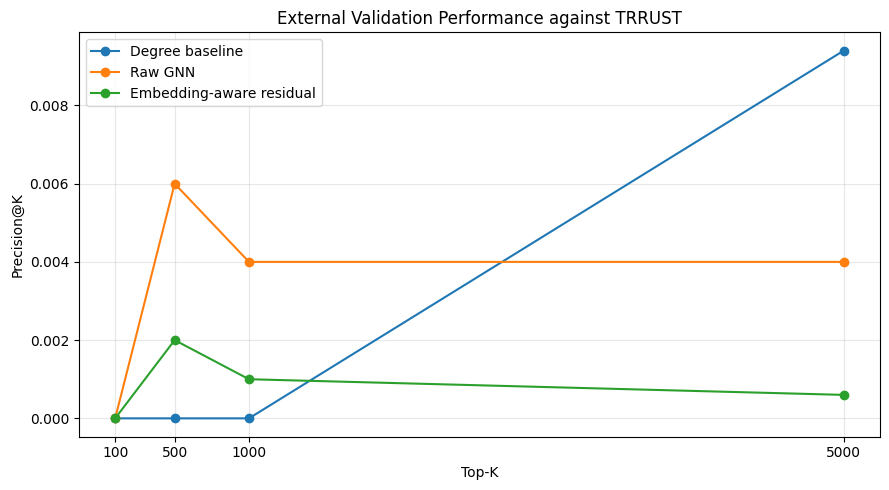

In [116]:
import matplotlib.pyplot as plt

# Prepare data
plot_df = validation_results.copy()

# Plot
plt.figure(figsize=(9, 5))

for ranking in plot_df["Ranking"].unique():
    subset = plot_df[plot_df["Ranking"] == ranking]
    plt.plot(
        subset["K"],
        subset["Precision_at_K"],
        marker="o",
        label=ranking
    )

plt.xlabel("Top-K")
plt.ylabel("Precision@K")
plt.title("External Validation Performance against TRRUST")
plt.xticks([100, 500, 1000, 5000])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()